
$\text{Janitza Current} = k I_{sm}  + I_{um} + \text{NTL}+ \sigma $

Where $k$ is CT scaling factor, $I_{sm}$ is the smart meter sum, $I_{um}$ is the unmetered load,NTL is the non techinal losses and $\sigma$ is the noise

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import math

FREQ = pd.Timedelta(minutes=15)

def parse_dnr(d): 
    """
    'D0411' -> 411
    'D1354' -> 1354
    """
    s = str(d).strip()
    if not s or not s.startswith("D"):
        return None
    digits = s[1:].lstrip("0")  # remove 'D' and leading zeros
    if digits == "":
        return None
    return int(digits)


def compute_ct_diagnostics(
    merged: pd.DataFrame,
    min_points: int = 50,
    min_current: float = 5.0,
) -> pd.DataFrame:
    """
    Per-substation diagnostics to detect CT scaling vs unmetered load.

    Expects columns in merged:
      substation_id, ts, I_total_sm, I_total_jn, n_mps, per_completed

    Assumes:
      - Janitza should be an upper bound for true current
        → in a physically consistent situation, I_total_sm <= I_total_jn
        (ignoring noise / mapping mistakes).
    """
    rows = []

    for sid, g in merged.groupby("substation_id"):
        g = g.copy()

        # Filter out very low currents (ratios get crazy near zero)
        mask = (g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)
        g = g[mask]
        if len(g) < min_points:
            continue  # not enough data

        x = g["I_total_sm"].values
        y = g["I_total_jn"].values

        # --- 1) Physical sanity: how often is SMD > Janitza? ---
        # This should basically never happen if topology + CT are correct
        sm_gt_jn = (g["I_total_sm"] > g["I_total_jn"])
        frac_sm_gt_jn = sm_gt_jn.mean()

        # --- 2) Unconstrained linear fit: y ≈ alpha * x + beta ---
        # (useful for R² / "does it look like a line?")
        alpha_ls, beta = np.polyfit(x, y, 1)

        y_pred = alpha_ls * x + beta
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

        # Correlation (shape similarity)
        corr = g["I_total_jn"].corr(g["I_total_sm"])

        # --- 3) Ratio-based view: y/x distribution ---
        ratio = g["I_total_jn"] / g["I_total_sm"]
        ratio = ratio.replace([np.inf, -np.inf], np.nan).dropna()
        ratio_median = float(ratio.median()) if not ratio.empty else np.nan
        ratio_std = float(ratio.std()) if not ratio.empty else np.nan
        ratio_min = float(ratio.min()) if not ratio.empty else np.nan
        ratio_p05 = float(ratio.quantile(0.05)) if len(ratio) > 0 else np.nan

        # --- 4) "CT scaling" factor under your physical constraint ---
        # Idea:
        #   - If JD is an upper bound, any scaling alpha must satisfy:
        #       alpha * I_total_sm <= I_total_jn  for all timestamps
        #     → alpha <= min_t (I_total_jn / I_total_sm) = ratio_min
        #
        #   - We also want alpha close to the "best" slope.
        #   - So we take the OLS slope *through origin* (no intercept)
        #     and then clip it to respect the constraint.
        #
        # OLS with intercept 0 : alpha0 = sum(x*y) / sum(x^2)
        if np.sum(x**2) > 0:
            alpha0 = float(np.sum(x * y) / np.sum(x**2))
        else:
            alpha0 = np.nan

        # Use a slightly robust upper bound: 5% quantile instead of raw min,
        # to avoid one glitch forcing alpha too low.
        # Physically allowed max alpha:
        alpha_max_phys = ratio_p05  # or ratio_min if you want it really strict

        if (not np.isnan(alpha0)) and (not np.isnan(alpha_max_phys)):
            # Constrained CT factor: best slope, but not larger than physical max
            alpha_ct = min(alpha0, alpha_max_phys)
        else:
            alpha_ct = np.nan

        # --- 5) Smart-meter completeness & expected alpha from coverage ---
        if "per_completed" in g:
            per_completed = float(g["per_completed"].max())
            # If someone stored it as 0–100, convert to 0–1
            if per_completed > 1.5:
                per_completed = per_completed / 100.0
        else:
            per_completed = np.nan

        n_mps = float(g["n_mps"].max()) if "n_mps" in g else np.nan

        # Expected alpha purely from missing meters:
        # per_completed = 0.9 → expected JD/SMD ≈ 1 / 0.9 ≈ 1.11
        if per_completed and per_completed > 0:
            expected_alpha = 1.0 / per_completed
        else:
            expected_alpha = np.nan

        if expected_alpha and (not np.isnan(expected_alpha)) and (not np.isnan(alpha_ct)):
            alpha_over_expected = alpha_ct / expected_alpha
        else:
            alpha_over_expected = np.nan

        rows.append({
            "substation_id": sid,
            # Unconstrained regression fit (with intercept)
            "alpha_ls": alpha_ls,
            "beta": beta,
            "r2": r2,
            "corr": corr,
            # Physically constrained CT-like factor
            "alpha_ct": alpha_ct,
            "alpha0_through_origin": alpha0,
            "ratio_min": ratio_min,
            "ratio_p05": ratio_p05,
            "ratio_median": ratio_median,
            "ratio_std": ratio_std,
            # Coverage + expectation
            "per_completed": per_completed,
            "n_mps": n_mps,
            "expected_alpha_from_coverage": expected_alpha,
            "alpha_over_expected": alpha_over_expected,
            # Conservation violation diagnostics
            "frac_sm_gt_jn": frac_sm_gt_jn,
            "n_points": len(g),
        })

    return pd.DataFrame(rows)


def plot_substation_timeseries(merged, sid, alpha=None, max_points=2000):
    g = merged[merged["substation_id"] == sid].sort_values("ts")
    if len(g) > max_points:
        g = g.iloc[:max_points]

    plt.figure(figsize=(12, 4))
    plt.plot(g["ts"], g["I_total_jn"], label="Janitza I_total")
    plt.plot(g["ts"], g["I_total_sm"], label="Smartmeters I_total")

    if alpha is not None:
        plt.plot(g["ts"], alpha * g["I_total_sm"], "--", label=f"SMD * {alpha:.2f}")

    plt.title(f"Substation {sid} – total current")
    plt.xlabel("Time")
    plt.ylabel("Current [A]")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_substation_scatter(merged, sid, alpha=None):
    g = merged[merged["substation_id"] == sid]

    plt.figure(figsize=(5, 5))
    plt.scatter(g["I_total_sm"], g["I_total_jn"], s=5, alpha=0.3, label="JD vs SMD")

    max_i = max(g["I_total_sm"].max(), g["I_total_jn"].max())
    plt.plot([0, max_i], [0, max_i], "k--", label="JD = SMD")

    if alpha is not None:
        xs = np.linspace(0, max_i, 100)
        plt.plot(xs, alpha * xs, label=f"JD = {alpha:.2f}·SMD")

    plt.xlabel("SMD I_total [A]")
    plt.ylabel("JD I_total [A]")
    plt.title(f"Substation {sid} – scatter")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_robust_comparison(stats_df, top_n=300):
    """
    Plots MAE (Amps), RMSE (Amps), and WAPE (%) stacked vertically.
    """
    # Take top N worst substations (by WAPE After)
    data = stats_df.head(top_n).copy()
    
    x = np.arange(len(data))
    width = 0.35
    subs = data.index.astype(str)
    
    # Increased figsize height (10 -> 14) and rows (2 -> 3)
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
    
    # --- PLOT 1: Absolute Error (MAE in Amps) ---
    ax1.bar(x - width/2, data["MAE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax1.bar(x + width/2, data["MAE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    
    ax1.set_ylabel('MAE [Amps]')
    ax1.set_title(f'Mean Absolute Error (MAE) - Top {top_n} Substations')
    ax1.legend()
    ax1.grid(True, axis='y', alpha=0.3)
    
    # --- PLOT 2: Root Mean Square Error (RMSE in Amps) ---
    ax2.bar(x - width/2, data["RMSE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax2.bar(x + width/2, data["RMSE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    
    ax2.set_ylabel('RMSE [Amps]')
    ax2.set_title('Root Mean Square Error (RMSE)')
    ax2.grid(True, axis='y', alpha=0.3)

    # --- PLOT 3: Relative Error (WAPE %) ---
    ax3.bar(x - width/2, data["WAPE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax3.bar(x + width/2, data["WAPE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    
    ax3.set_ylabel('WAPE [%]')
    ax3.set_title('Weighted Percentage Error (WAPE)')
    ax3.set_xticks(x)
    ax3.set_xticklabels(subs, rotation=90)
    ax3.grid(True, axis='y', alpha=0.3)
    
    # Add n_mps labels only on the bottom plot to reduce clutter
    for i, n in enumerate(data["n_mps"]):
        # Place text slightly above the highest bar in the WAPE plot
        y_pos = max(data["WAPE_Before"].iloc[i], data["WAPE_After"].iloc[i])
        offset = 0.05 * data["WAPE_Before"].max() # Dynamic offset based on max value
        
        ax3.text(i, y_pos + offset, 
                 f"n={int(n)}", ha='center', fontsize=8, rotation=90)

    plt.tight_layout()
    plt.show()


def plot_substation_timeseries_grid(
    merged: pd.DataFrame,
    summary: pd.DataFrame,
    substation_ids=None,
    min_per_completed: float = 0.7,
    max_plots: int = 12,
    cols: int = 4,
    max_points: int = 2000,
):
    """
    Grid of time series plots per substation.

    For each substation:
      - plots Janitza I_total_jn
      - plots Smartmeter I_total_sm
      - if alpha_ct is available in `summary`, also plots alpha_ct * I_total_sm

    Each subplot has its own y-axis scale (no shared y), but x (time) is shared.
    """

    # --- choose which substations to plot ---
    if substation_ids is not None:
        # Use explicit list, limited to max_plots
        sids = list(substation_ids)[:max_plots]
        cand = summary[summary["substation_id"].isin(sids)].copy()
    else:
        # Use summary to pick "interesting" substations
        cand = summary[summary["per_completed"] >= min_per_completed].copy()

        # Sort by alpha_over_expected if available, else by substation_id
        if "alpha_over_expected" in cand.columns:
            cand = cand.sort_values("alpha_over_expected", ascending=False)
        else:
            cand = cand.sort_values("substation_id")

        cand = cand.head(max_plots)
        sids = cand["substation_id"].tolist()

    if not sids:
        print("No substations to plot (check filters or substation_ids).")
        return

    # Make it easy to look up per-substation diagnostics
    summary_idx = summary.set_index("substation_id")

    # --- create grid of subplots ---
    n_plots = len(sids)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(6 * cols, 3 * rows),
        sharex=True,
        sharey=False,  # <<< each substation has its own y-scale
    )
    axes = np.array(axes).reshape(-1)

    for ax, sid in zip(axes, sids):
        g = merged[merged["substation_id"] == sid].sort_values("ts")

        if g.empty:
            ax.set_visible(False)
            continue

        if len(g) > max_points:
            g = g.iloc[:max_points]

        # Get alpha_ct if present
        alpha = None
        if "alpha_ct" in summary_idx.columns and sid in summary_idx.index:
            alpha_val = summary_idx.loc[sid, "alpha_ct"]
            try:
                alpha = float(alpha_val)
            except Exception:
                alpha = None

        # Plot original currents
        ax.plot(g["ts"], g["I_total_jn"], label="Janitza I_total")
        ax.plot(g["ts"], g["I_total_sm"], label="Smartmeters I_total")

        # Optional CT-scaled smartmeter line
        if alpha is not None and np.isfinite(alpha):
            ax.plot(g["ts"], alpha * g["I_total_sm"], "--", label=f"SMD × {alpha:.2f}")

        # Build a small informative title
        title = f"Sub {sid}"
        if "corr" in summary_idx.columns and sid in summary_idx.index:
            corr = summary_idx.loc[sid, "corr"]
            try:
                title += f"\nρ={corr:.2f}"
            except Exception:
                pass
        if "per_completed" in summary_idx.columns and sid in summary_idx.index:
            per = summary_idx.loc[sid, "per_completed"]
            try:
                title += f", per={per:.2f}"
            except Exception:
                pass

        ax.set_title(title, fontsize=9)
        ax.set_ylabel("I_total [A]")
        ax.legend(fontsize=8)

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # x-label only on bottom row
    for i, ax in enumerate(axes[:n_plots]):
        row_idx = i // cols
        if row_idx == rows - 1:
            ax.set_xlabel("Time")

    fig.suptitle("Substation total current – JD vs SM (with CT scaling)", y=0.98)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


def calculate_robust_metrics(df_in, sm_col="I_total_sm", jn_col="I_total_jn", min_current_mape=5.0):
    """
    Calculates row-wise error metrics and aggregates them per substation.
    """
    df = df_in.copy()
    
    # 1. Basic Difference
    df["diff"] = df[sm_col] - df[jn_col]
    df["abs_diff"] = df["diff"].abs()
    df["sq_diff"] = df["diff"] ** 2
    
    # 2. Standard MAPE (Unstable near zero, filtered by threshold)
    # We only calculate this where current > min_current_mape (e.g., 5 Amps)
    high_load_mask = df[sm_col] > min_current_mape
    df["mape_filtered"] = np.nan
    df.loc[high_load_mask, "mape_filtered"] = (
        100 * df.loc[high_load_mask, "abs_diff"] / df.loc[high_load_mask, sm_col]
    )

    # 3. Symmetric MAPE (0-100% scale)
    # Formula: |sm - jn| / ((|sm| + |jn|) / 2)
    # Good because it doesn't explode if SM is 0 but JN is 1
    denom = (df[sm_col].abs() + df[jn_col].abs()) / 2
    df["smape"] = 100 * df["abs_diff"] / denom.replace(0, np.nan)

    # --- AGGREGATION ---
    stats = df.groupby("substation_id").agg(
        # Context
        n_points     = (sm_col, "count"),
        n_mps        = ("n_mps", "max"),
        per_completed= ("per_completed", "max"),
        
        # Absolute Errors (Amps)
        MAE          = ("abs_diff", "mean"),
        RMSE         = ("sq_diff", lambda x: np.sqrt(x.mean())),
        
        # Percentage Errors
        # 1. Mean of the filtered row-wise MAPE
        MAPE_filtered_mean = ("mape_filtered", "mean"),
        
        # 2. SMAPE
        SMAPE_mean = ("smape", "mean"),
        
        # 3. WAPE (Weighted APE) -> Sum(AbsDiff) / Sum(SM)
        # We calculate sums here, then divide them in the next step
        sum_abs_diff = ("abs_diff", "sum"),
        sum_sm_total = (sm_col, "sum")
    )
    
    # Calculate WAPE (The most robust percentage metric for energy)
    stats["WAPE"] = 100 * stats["sum_abs_diff"] / stats["sum_sm_total"].replace(0, np.nan)
    
    return stats


def plot_scatter_grid(
    merged: pd.DataFrame,
    summary: pd.DataFrame,
    min_per_completed: float = 0.9,
    max_plots: int = 12,
    cols: int = 4,
    min_points: int = 50,
    min_current: float = 5.0,
    normalize: bool = True,   # <--- NEW
):
    """
    Make a grid of scatter plots:
        x = I_total_sm (smartmeters)
        y = I_total_jn (Janitza)

    When normalize=True, both axes in each subplot are scaled so that
    max(I_total_sm, I_total_jn) for that substation becomes 1.0.
    The slope α is preserved.
    """

    # Filter to reasonably complete substations
    cand = summary[
        (summary["per_completed"] >= min_per_completed) &
        (summary["n_points"] >= min_points)
    ].copy()

    if cand.empty:
        print("No substations meet the per_completed and n_points filters.")
        return

    # Sort e.g. by alpha_over_expected so the “worst” ones come first
    cand = cand.sort_values("alpha_over_expected", ascending=False)

    # Limit how many we plot
    cand = cand.head(max_plots)

    n_plots = len(cand)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(4 * cols, 4 * rows),
        sharex=not normalize,   # if normalized, each axes gets its own [0,1]
        sharey=not normalize,
    )
    axes = np.array(axes).reshape(-1)

    # If NOT normalizing, we still want a global max
    global_max = 0.0
    if not normalize:
        for sid in cand["substation_id"]:
            g = merged[merged["substation_id"] == sid].copy()
            mask = (g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)
            g = g[mask]
            if g.empty:
                continue
            local_max = max(g["I_total_sm"].max(), g["I_total_jn"].max())
            global_max = max(global_max, local_max)

        if global_max == 0:
            print("All filtered substations have zero currents after filtering.")
            return

    # Actual plotting
    for ax, (_, row) in zip(axes, cand.iterrows()):
        sid = row["substation_id"]
        alpha = row["alpha_ct"]
        per_completed = row["per_completed"]
        alpha_over_exp = row["alpha_over_expected"]
        r2 = row["r2"]

        g = merged[merged["substation_id"] == sid].copy()
        mask = (g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)
        g = g[mask]
        if g.empty:
            ax.set_visible(False)
            continue

        if normalize:
            # scale currents so that the largest current for this substation is 1.0
            local_max = max(g["I_total_sm"].max(), g["I_total_jn"].max())
            if local_max == 0:
                ax.set_visible(False)
                continue
            x = g["I_total_sm"] / local_max
            y = g["I_total_jn"] / local_max
            xs = np.linspace(0, 1, 100)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        else:
            x = g["I_total_sm"]
            y = g["I_total_jn"]
            xs = np.linspace(0, global_max, 100)
            ax.set_xlim(0, global_max)
            ax.set_ylim(0, global_max)

        # Scatter points
        ax.scatter(x, y, s=5, alpha=0.3)

        # Diagonal JD = SMD
        ax.plot(xs, xs, "k--", linewidth=1, label="JD = SMD")

        # Fitted CT scaling line JD = alpha * SMD
        ax.plot(xs, alpha * xs, linewidth=1, label=f"JD = {alpha:.2f}·SMD")

        ax.set_title(
            f"Sub {sid}\n"
            f"α={alpha:.2f}, r²={r2:.2f}\n"
            f"per={per_completed:.2f}, α/α_exp={alpha_over_exp:.2f}"
        )

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # Axis labels only on outer edges
    for i, ax in enumerate(axes[:n_plots]):
        row_idx = i // cols
        col_idx = i % cols
        if row_idx == rows - 1:
            ax.set_xlabel("I_total_sm (normalized)" if normalize else "I_total_sm [A]")
        if col_idx == 0:
            ax.set_ylabel("I_total_jn (normalized)" if normalize else "I_total_jn [A]")

    plt.suptitle(
        f"JD vs SMD scatter – substations with per_completed ≥ {min_per_completed}",
        y=0.98,
    )
    plt.tight_layout()
    plt.show()

In [2]:
sm_current_path = "../data/smartmeter_15min_all_from_devices_20250801_20251101_Current.parquet"
jn_current_path = "../data/janitza_3phase_I_all_20250801_0000_20251101_0000.parquet"

# read data
df_sm_current = pd.read_parquet(sm_current_path)
df_jn_current = pd.read_parquet(jn_current_path)

# exclude substations (Janitza side)
exclude_dnr = ["D0303", "D1454","D1554","D1049"]
df_jn_current = df_jn_current[~df_jn_current["dnr_str"].isin(exclude_dnr)].copy()

# add substation_id
df_jn_current["substation_id"] = df_jn_current["dnr_str"].map(parse_dnr)

# timestamps
df_sm_current["ts"] = pd.to_datetime(df_sm_current["ts"])
df_jn_current["ts"] = pd.to_datetime(df_jn_current["ts"], utc=True).dt.tz_localize(None)

# keep only substations that exist in Janitza
jn_substations = df_jn_current["substation_id"].dropna().unique()
df_sm_current = df_sm_current[df_sm_current["substation_id"].isin(jn_substations)].copy()

# --- FIX: robust 15-min snapping for Janitza (prevents ceil gaps) ---
tol = pd.Timedelta(seconds=10)

ts_raw = df_jn_current["ts"]
t_floor = ts_raw.dt.floor("15min")
offset = ts_raw - t_floor

df_jn_current["ts"] = t_floor.where(offset <= tol, ts_raw.dt.ceil("15min"))

# trim to same max timestamp (optional but fine)
max_ts_sm = df_sm_current["ts"].max()
df_sm_current = df_sm_current[df_sm_current["ts"] < max_ts_sm].copy()
df_jn_current = df_jn_current[df_jn_current["ts"] < max_ts_sm].copy()

# --- FIX: aggregate Janitza collisions instead of drop_duplicates ---
num_cols = ["I_a", "I_b", "I_c", "I_total"]
df_jn_current = (
    df_jn_current
    .groupby(["substation_id", "ts"], as_index=False)[num_cols]
    .mean()
)

# --- NEW: build COMMON bins (intersection) so both datasets end with same keys ---
jn_bins = df_jn_current[["substation_id", "ts"]].drop_duplicates()
sm_bins = df_sm_current[["substation_id", "ts"]].drop_duplicates()

common_bins = jn_bins.merge(sm_bins, on=["substation_id", "ts"], how="inner")

# filter BOTH to intersection bins
df_jn_good = df_jn_current.merge(common_bins, on=["substation_id", "ts"], how="inner")
df_sm_good = df_sm_current.merge(common_bins, on=["substation_id", "ts"], how="inner")

# sanity checks
print("Original:", df_jn_current.shape, df_sm_current.shape)
print("Common-bin:", df_jn_good.shape, df_sm_good.shape)

# confirm no duplicate keys remain
print("Duplicate keys in JN good:", df_jn_good.duplicated(["substation_id","ts"]).sum())
print("Duplicate keys in SM good:", df_sm_good.duplicated(["substation_id","ts"]).sum())


Original: (568611, 6) (574071, 8)
Common-bin: (568602, 6) (568602, 8)
Duplicate keys in JN good: 0
Duplicate keys in SM good: 0


In [3]:
df_merged = df_sm_good.merge(
    df_jn_good,
    on=["substation_id", "ts"],
    how="inner",             # intersection only
    suffixes=("_sm", "_jn"),
    validate="one_to_one"    # safety check: raises if keys aren't 1:1
)
for col in ["I_a", "I_b", "I_c", "I_total"]:
    df_merged[f"{col}_diff"] = df_merged[f"{col}_sm"] - df_merged[f"{col}_jn"]

df_merged[["I_a_diff", "I_b_diff", "I_c_diff", "I_total_diff"]].describe()

print("Merged shape:",df_merged.shape)
df_computed = compute_ct_diagnostics(df_merged)

Merged shape: (568602, 16)


If the issue is CT scaling then we expect the dots to be spread around the corrected line

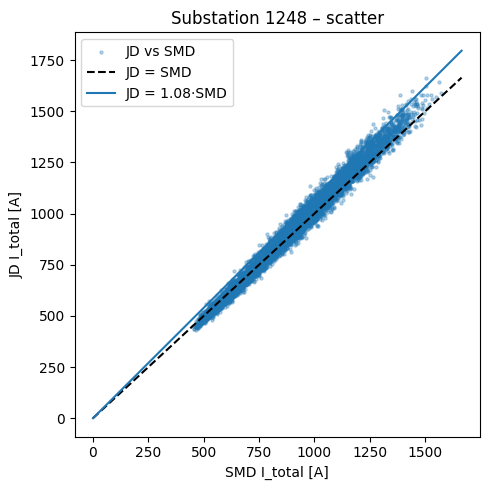

In [4]:
substation_id = 1248
plot_substation_scatter(
    merged=df_merged,
    sid=substation_id,
    alpha=df_computed.loc[df_computed["substation_id"] == substation_id, "alpha_ls"].values[0]
)

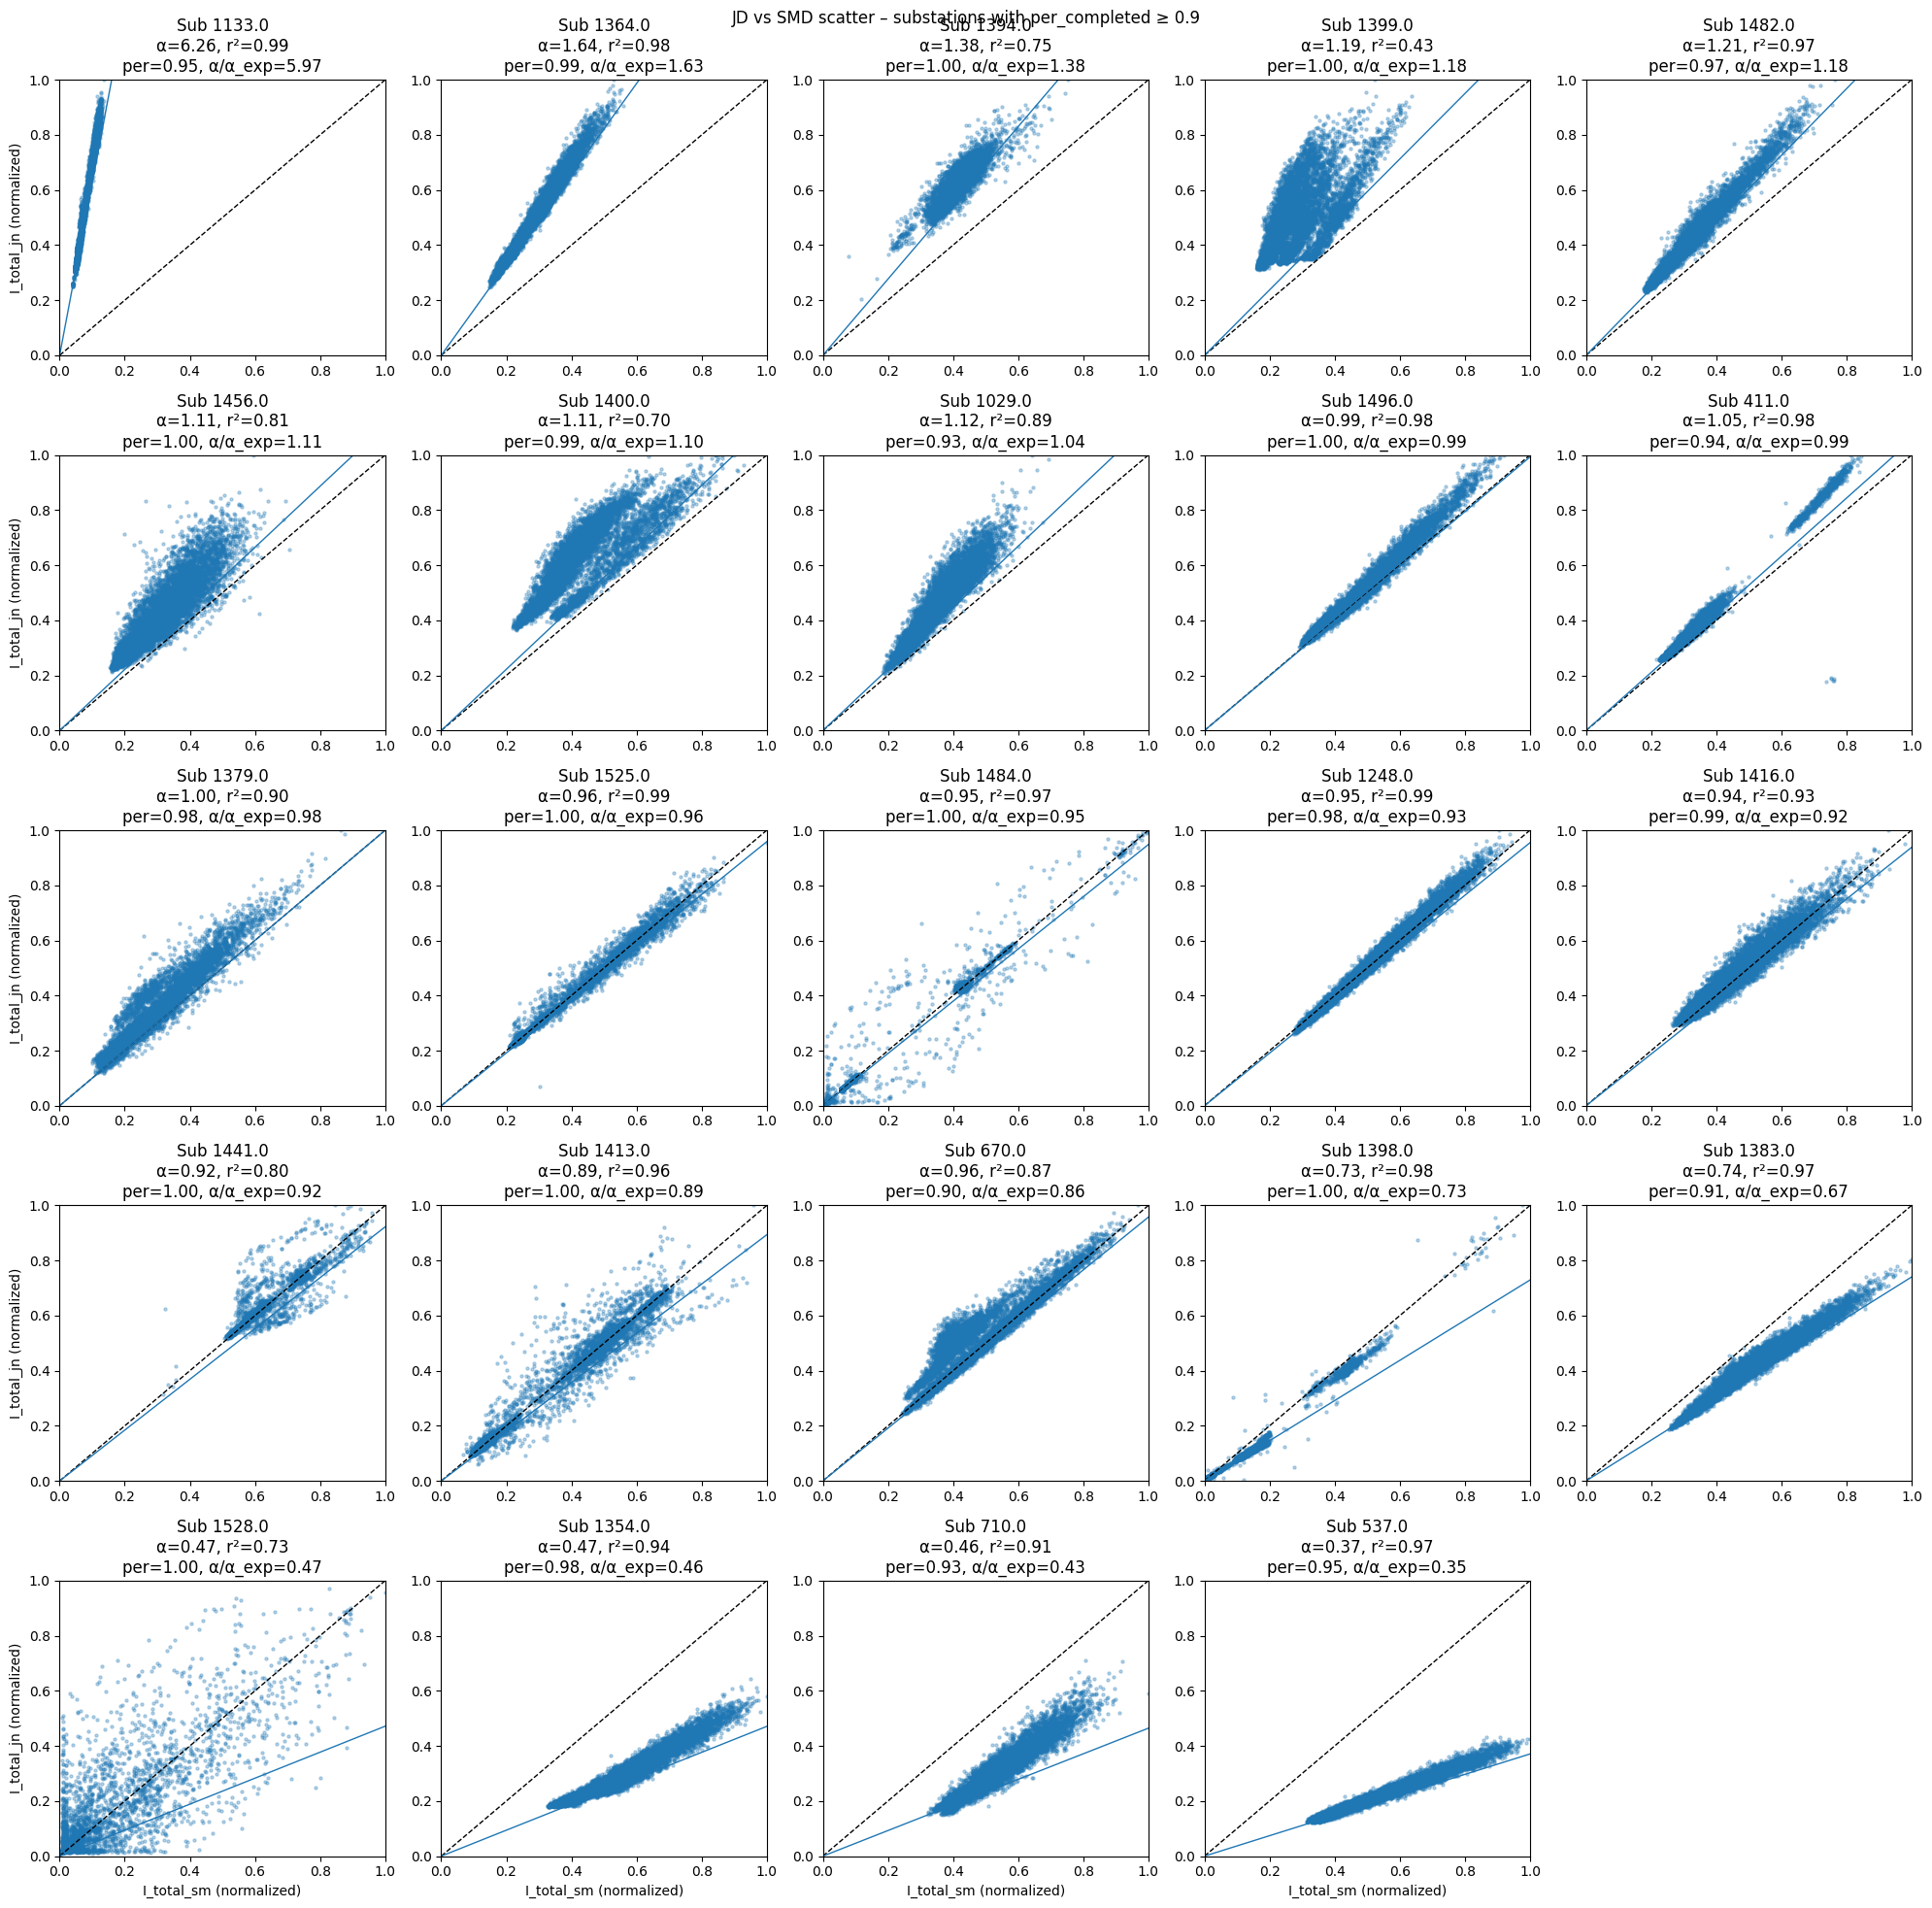

In [5]:
plot_scatter_grid(
    merged=df_merged,
    summary=df_computed,
    min_per_completed=0.9,
    max_plots=24,
    cols=5,
)

                MAE_Before    MAE_After  WAPE_Before  WAPE_After  RMSE_Before  \
substation_id                                                                   
1528             26.599238    80.953040    47.409634  144.288120    59.145941   
1534           2072.528177  3346.225599    72.246852  116.647034  2466.998364   
1399            309.697412   197.090331    73.759921   46.940551   337.393154   
1400            164.874457   112.102614    44.286793   30.111791   177.410649   
710             200.144671   123.447556    41.773586   25.765598   202.284518   

                RMSE_After  n_mps  
substation_id                      
1528            168.345855      2  
1534           4087.945006      4  
1399            225.991225    245  
1400            126.309564    136  
710             153.988604    282  


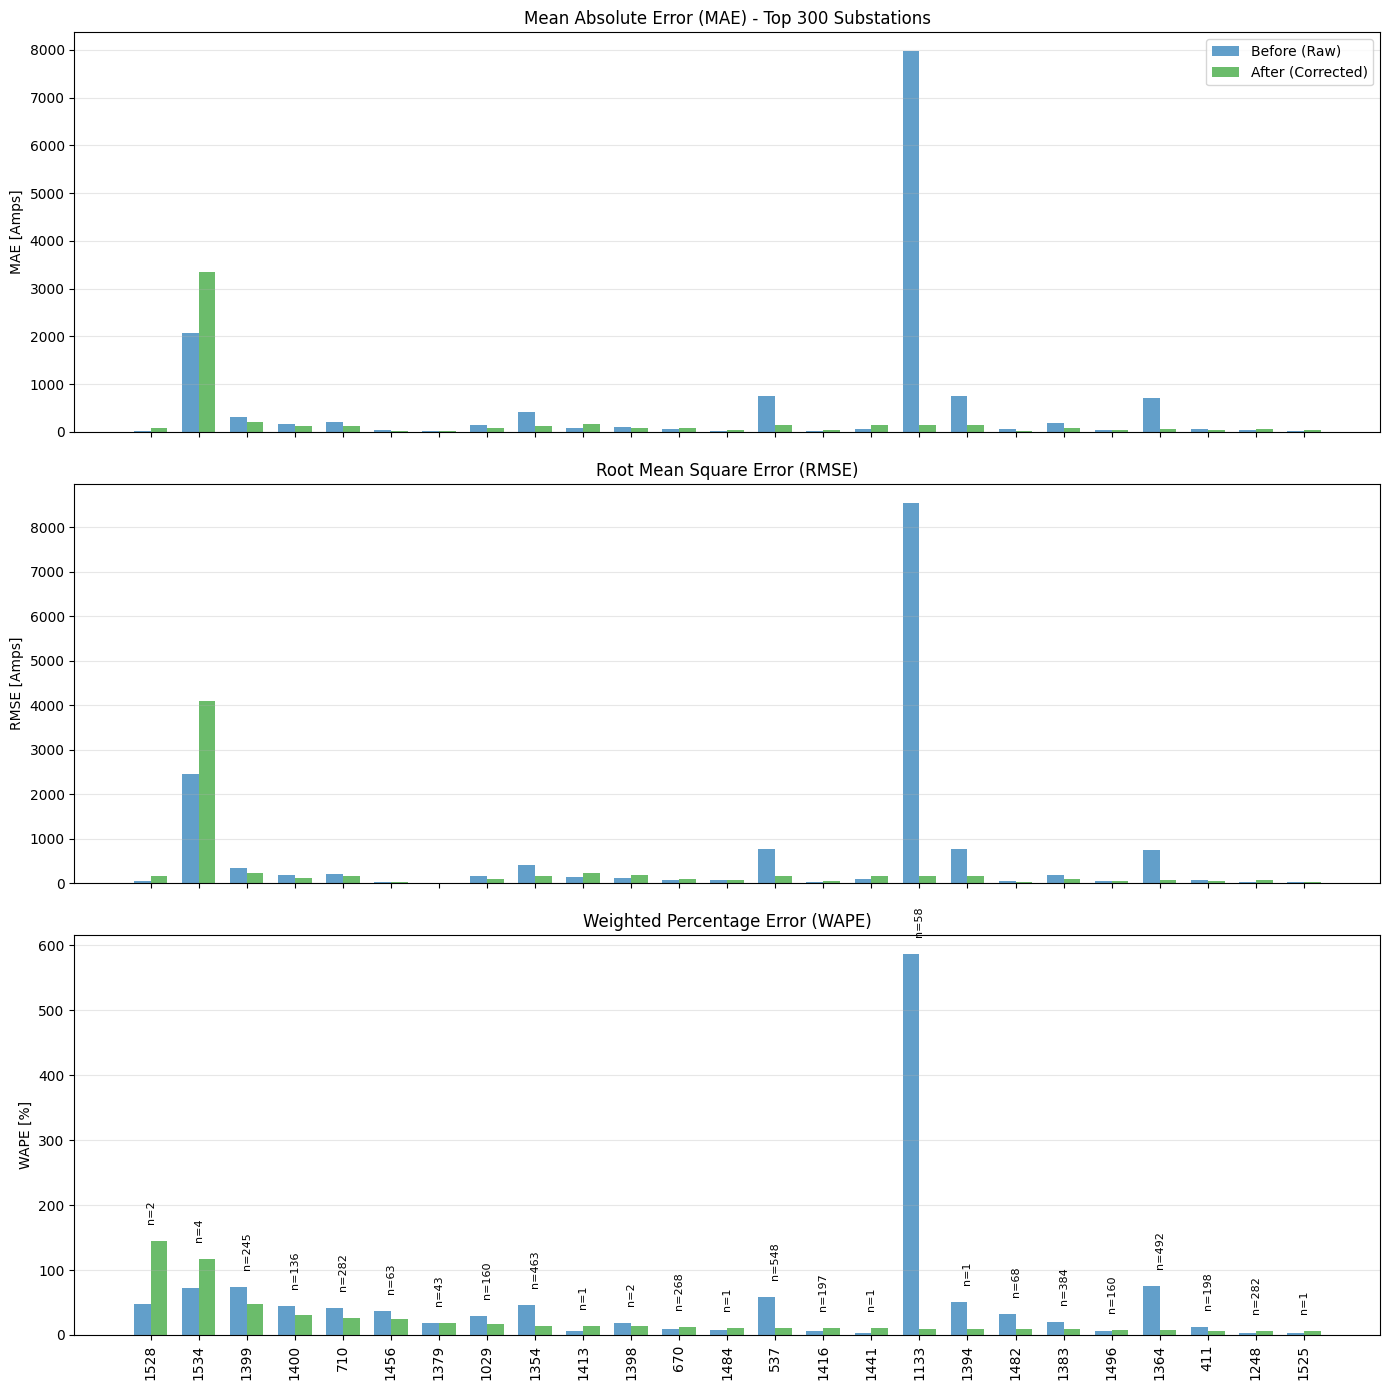

In [6]:

# ==========================================
# 1. PREPARE DATA (Merged only, no correction yet)
# ==========================================
df_metrics_before = calculate_robust_metrics( df_merged,sm_col="I_total_sm",jn_col="I_total_jn")

# ==========================================
# 2. APPLY CORRECTION & RE-CALCULATE
# ==========================================
df_after = df_merged.copy()

# Merge alpha_ct
df_after = df_after.merge(
    df_computed[["substation_id", "alpha_ct"]],
    on="substation_id",
    how="left",
)
df_after["alpha_ct"] = df_after["alpha_ct"].fillna(1.0)

# Correct Janitza
df_after["I_total_jn_corr"] = df_after["I_total_jn"] / df_after["alpha_ct"]

# Calculate metrics on corrected data
df_metrics_after = calculate_robust_metrics(
    df_after, 
    sm_col="I_total_sm", 
    jn_col="I_total_jn_corr"
)

# ==========================================
# 3. COMBINE & FILTER
# ==========================================
cutoff = 0.9
min_num = 1

# Filter Index based on coverage
valid_ids = df_metrics_before[
    (df_metrics_before["per_completed"] >= cutoff) & 
    (df_metrics_before["n_mps"] >= min_num)
].index

# Select valid rows
stats_final = pd.DataFrame({
    "MAE_Before": df_metrics_before.loc[valid_ids, "MAE"],
    "MAE_After":  df_metrics_after.loc[valid_ids, "MAE"],
    
    "WAPE_Before": df_metrics_before.loc[valid_ids, "WAPE"],
    "WAPE_After":  df_metrics_after.loc[valid_ids, "WAPE"],
    
    "RMSE_Before": df_metrics_before.loc[valid_ids, "RMSE"],
    "RMSE_After":  df_metrics_after.loc[valid_ids, "RMSE"],
    
    "n_mps": df_metrics_before.loc[valid_ids, "n_mps"]
})

# Sort by Improved WAPE
stats_final = stats_final.sort_values("WAPE_After", ascending=False)

print(stats_final.head())


plot_robust_comparison(stats_final)



Change in the ratio of SMD vs Janitza and after correction

Ratio can be misleading here are stations ploted with old smart meter current and corrected.

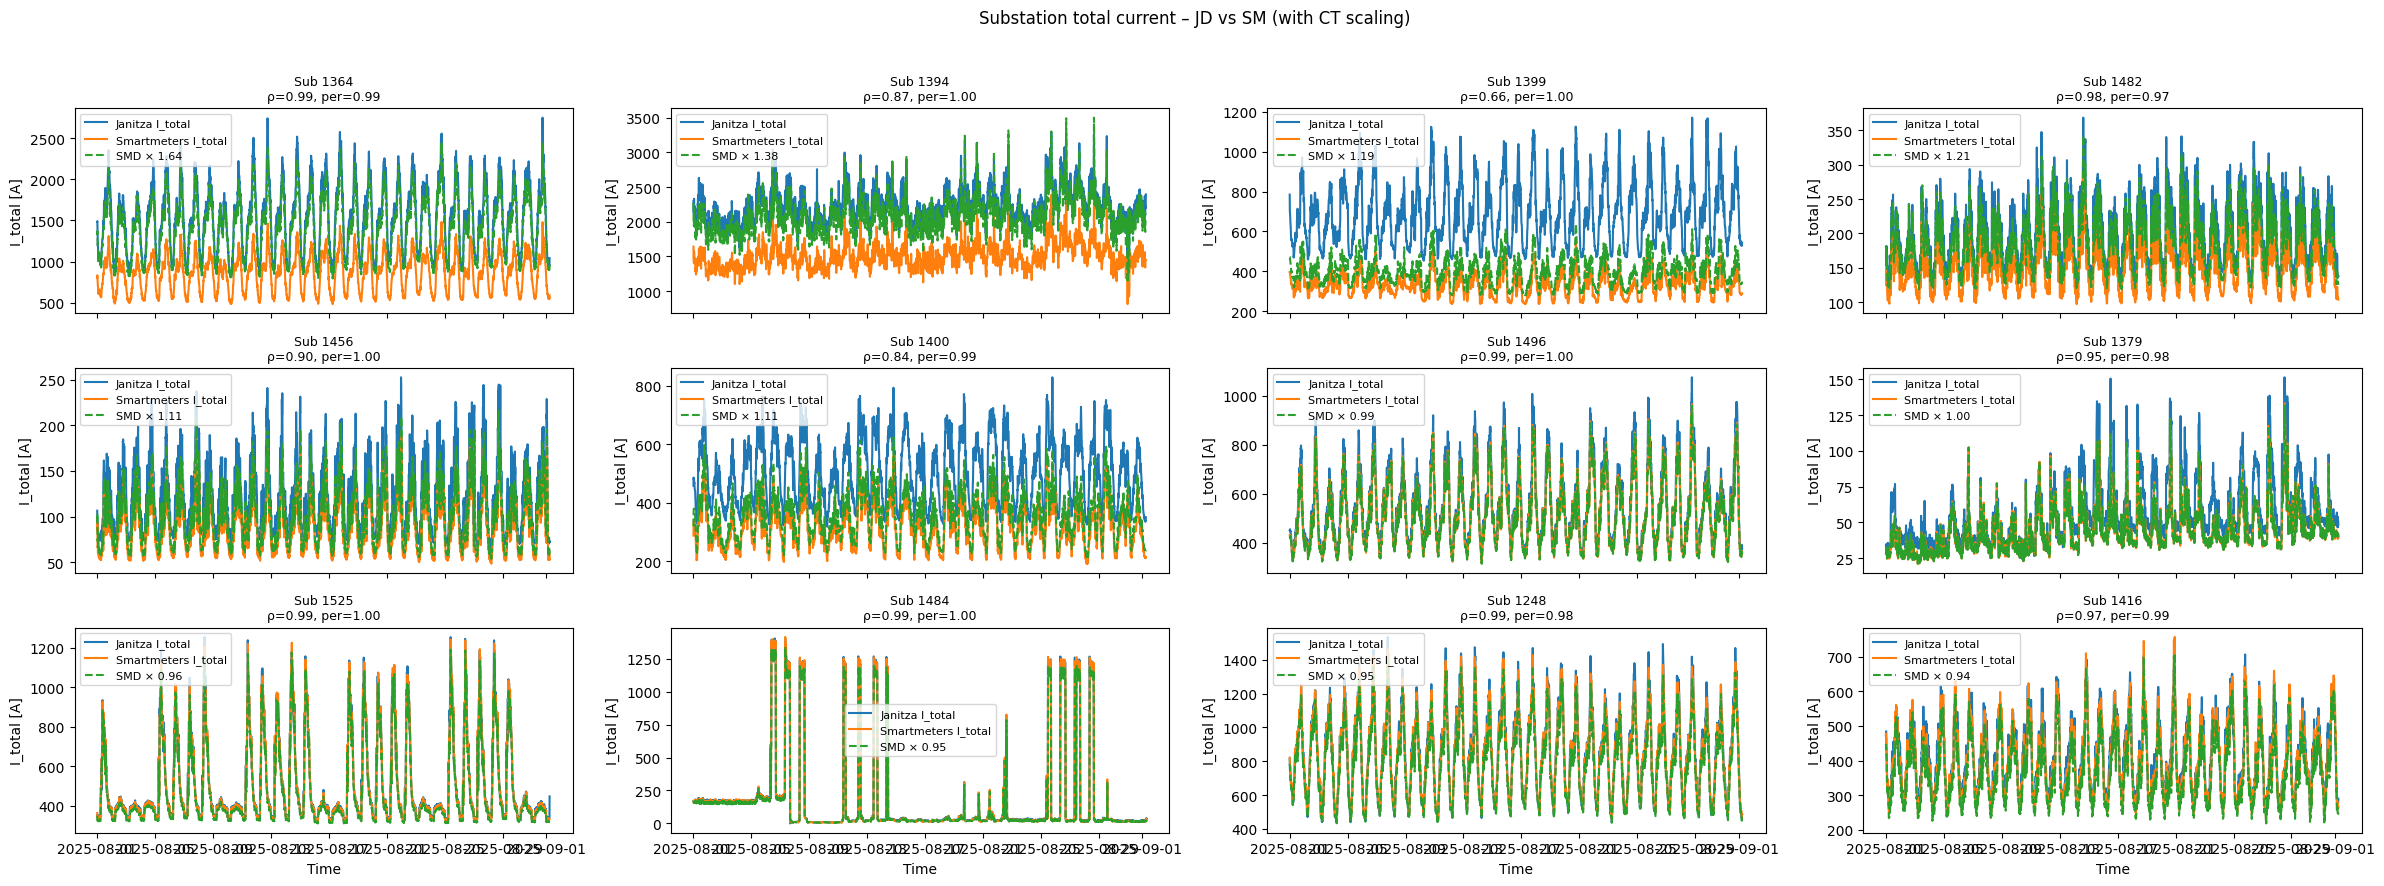

In [7]:
plot_substation_timeseries_grid(
    merged=df_merged,
    summary=df_computed,
    min_per_completed=0.96,
    max_plots=12,
    cols=4,
    max_points=3000,
)

c:\Users\jaqui\anaconda3\envs\main\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8480.
  res = hypotest_fun_out(*samples, **kwds)


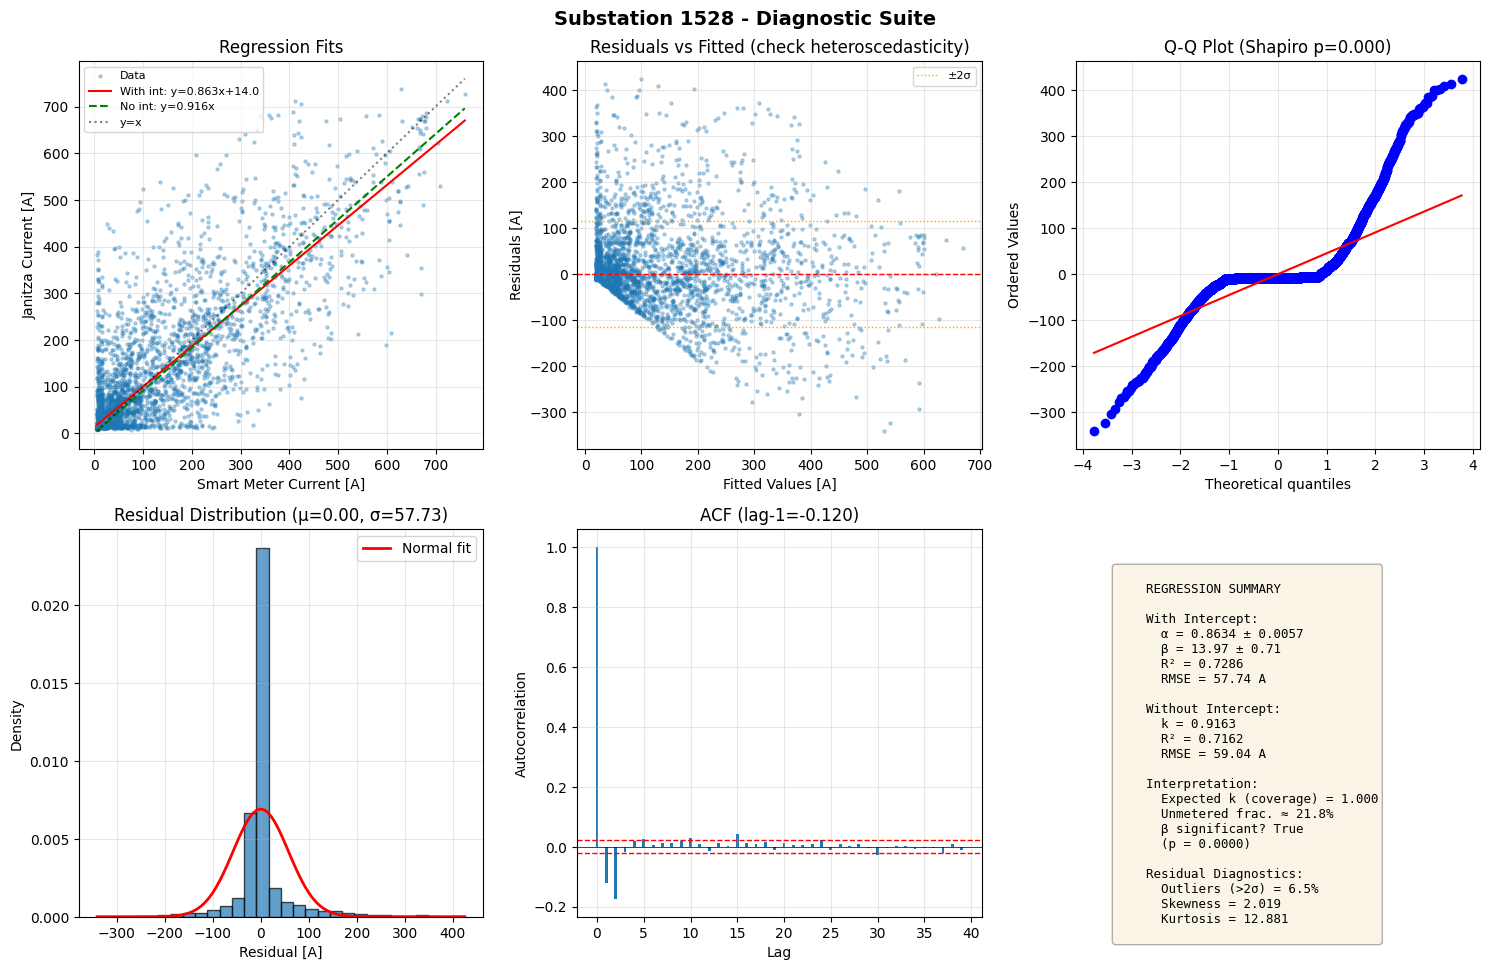


INTERPRETATION FOR SUBSTATION 1528

1. OVERALL FIT QUALITY:
   ✗ Poor linear relationship (R² = 0.7286) - check data quality

2. CT SCALING FACTOR (α):
   ? α=0.863 vs expected 1.000 - investigate further

3. INTERCEPT (β) - UNMETERED LOADS:
   ! β = 14.0 A is statistically significant (95% CI: [12.6, 15.4])
   → Estimated unmetered load: ~21.8% of total
     (This could be: street lights, substation aux, incomplete metering)

4. RESIDUAL ANALYSIS:
   ✓ Low autocorrelation (ρ₁=-0.120) - residuals appear random
   ! Non-normal residuals (Shapiro p=0.0000)
     → May indicate outliers, NTL events, or model mis-specification

5. NON-TECHNICAL LOSS INDICATORS:
   ! 6.5% of points are outliers (>2σ)
     → Investigate these timestamps for potential NTL or data errors




In [8]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from typing import Tuple, Dict

def advanced_regression_analysis(
    merged: pd.DataFrame,
    sid: int,
    min_current: float = 5.0
) -> Dict:
    """
    Perform comprehensive regression analysis for a single substation.
    Returns diagnostics to help identify CT scaling, unmetered loads, and NTL.
    """
    g = merged[merged["substation_id"] == sid].copy()
    
    # Filter low currents
    mask = (g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)
    g = g[mask]
    
    if len(g) < 50:
        return {"error": "Insufficient data points"}
    
    x = g["I_total_sm"].values.reshape(-1, 1)
    y = g["I_total_jn"].values
    
    results = {}
    
    # ===== 1. REGRESSION WITH INTERCEPT =====
    # Model: y = alpha * x + beta + epsilon
    model_with_intercept = LinearRegression(fit_intercept=True)
    model_with_intercept.fit(x, y)
    
    alpha = model_with_intercept.coef_[0]
    beta = model_with_intercept.intercept_
    y_pred = model_with_intercept.predict(x)
    residuals = y - y_pred
    
    # R² and standard error
    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    
    n = len(y)
    p = 2  # number of parameters (slope + intercept)
    mse = ss_res / (n - p)
    rmse = np.sqrt(mse)
    
    # Standard errors for parameters (confidence intervals)
    # SE(beta) = sqrt(MSE * (1/n + x_mean²/SS_x))
    x_flat = x.flatten()
    x_mean = x_flat.mean()
    ss_x = np.sum((x_flat - x_mean) ** 2)
    
    se_alpha = np.sqrt(mse / ss_x)
    se_beta = np.sqrt(mse * (1/n + x_mean**2 / ss_x))
    
    # 95% confidence intervals
    t_crit = stats.t.ppf(0.975, n - p)
    alpha_ci = (alpha - t_crit * se_alpha, alpha + t_crit * se_alpha)
    beta_ci = (beta - t_crit * se_beta, beta + t_crit * se_beta)
    
    results['with_intercept'] = {
        'alpha': alpha,
        'beta': beta,
        'r2': r2,
        'rmse': rmse,
        'alpha_ci': alpha_ci,
        'beta_ci': beta_ci,
        'se_alpha': se_alpha,
        'se_beta': se_beta,
    }
    
    # ===== 2. REGRESSION THROUGH ORIGIN =====
    # Model: y = k * x + epsilon (no intercept)
    model_no_intercept = LinearRegression(fit_intercept=False)
    model_no_intercept.fit(x, y)
    
    k = model_no_intercept.coef_[0]
    y_pred_no_int = model_no_intercept.predict(x)
    residuals_no_int = y - y_pred_no_int
    
    ss_res_no_int = np.sum(residuals_no_int ** 2)
    r2_no_int = 1 - ss_res_no_int / ss_tot
    rmse_no_int = np.sqrt(ss_res_no_int / (n - 1))
    
    results['no_intercept'] = {
        'k': k,
        'r2': r2_no_int,
        'rmse': rmse_no_int,
    }
    
    # ===== 3. RESIDUAL ANALYSIS =====
    # Check for patterns in residuals that might indicate NTL or other issues
    
    # Autocorrelation of residuals (colored noise indicator)
    if len(residuals) > 10:
        acf_lag1 = np.corrcoef(residuals[:-1], residuals[1:])[0, 1]
    else:
        acf_lag1 = np.nan
    
    # Heteroscedasticity: does variance change with x?
    # Split into low/high current and compare variances
    median_x = np.median(x_flat)
    low_curr_residuals = residuals[x_flat < median_x]
    high_curr_residuals = residuals[x_flat >= median_x]
    
    if len(low_curr_residuals) > 5 and len(high_curr_residuals) > 5:
        var_ratio = np.var(high_curr_residuals) / np.var(low_curr_residuals)
        # Levene's test for equal variances
        levene_stat, levene_p = stats.levene(low_curr_residuals, high_curr_residuals)
    else:
        var_ratio = np.nan
        levene_stat, levene_p = np.nan, np.nan
    
    # Normality test (Shapiro-Wilk)
    if len(residuals) >= 3:
        shapiro_stat, shapiro_p = stats.shapiro(residuals)
    else:
        shapiro_stat, shapiro_p = np.nan, np.nan
    
    results['residual_diagnostics'] = {
        'mean': np.mean(residuals),
        'std': np.std(residuals),
        'skewness': stats.skew(residuals),
        'kurtosis': stats.kurtosis(residuals),
        'acf_lag1': acf_lag1,
        'var_ratio_high_low': var_ratio,
        'levene_p': levene_p,
        'shapiro_p': shapiro_p,
    }
    
    # ===== 4. INTERPRETATION METRICS =====
    # Compare intercept to expected unmetered load
    per_completed = g["per_completed"].max() if "per_completed" in g else np.nan
    
    if not np.isnan(per_completed) and per_completed > 0:
        # Expected k from coverage: if 90% meters, expect k ≈ 1/0.9 = 1.11
        expected_k = 1.0 / per_completed
        
        # Estimate unmetered load as fraction of total
        # If alpha ≈ 1 (no CT error), then beta should represent unmetered
        avg_smart_meter = np.mean(x_flat)
        unmetered_fraction = beta / (alpha * avg_smart_meter + beta) if (alpha * avg_smart_meter + beta) > 0 else np.nan
        
        # Is the intercept statistically significant?
        t_stat_beta = beta / se_beta if se_beta > 0 else np.nan
        p_value_beta = 2 * (1 - stats.t.cdf(abs(t_stat_beta), n - p)) if not np.isnan(t_stat_beta) else np.nan
        
    else:
        expected_k = np.nan
        unmetered_fraction = np.nan
        t_stat_beta = np.nan
        p_value_beta = np.nan
    
    results['interpretation'] = {
        'expected_k_from_coverage': expected_k,
        'unmetered_fraction_estimate': unmetered_fraction,
        'intercept_t_statistic': t_stat_beta,
        'intercept_p_value': p_value_beta,
        'intercept_significant': p_value_beta < 0.05 if not np.isnan(p_value_beta) else None,
    }
    
    # ===== 5. NTL/ANOMALY INDICATORS =====
    # Large residuals might indicate NTL or errors
    residual_threshold = 2 * rmse
    large_residuals = np.abs(residuals) > residual_threshold
    frac_outliers = np.mean(large_residuals)
    
    # Time-based analysis: are there periods with systematic errors?
    if 'ts' in g.columns:
        g_with_res = g.copy()
        g_with_res['residual'] = residuals
        g_with_res['abs_residual'] = np.abs(residuals)
        
        # Check if residuals are time-correlated (might indicate systematic NTL)
        hourly_avg_residual = g_with_res.groupby(g_with_res['ts'].dt.hour)['abs_residual'].mean()
        residual_variation_by_hour = hourly_avg_residual.std() / hourly_avg_residual.mean() if hourly_avg_residual.mean() > 0 else np.nan
    else:
        residual_variation_by_hour = np.nan
    
    results['ntl_indicators'] = {
        'frac_outliers': frac_outliers,
        'max_abs_residual': np.max(np.abs(residuals)),
        'residual_variation_by_hour': residual_variation_by_hour,
    }
    
    results['raw_data'] = {
        'x': x_flat,
        'y': y,
        'residuals': residuals,
        'n_points': n,
    }
    
    return results


def plot_diagnostic_suite(results: Dict, sid: int):
    """Create comprehensive diagnostic plots for a substation."""
    
    if 'error' in results:
        print(f"Cannot plot: {results['error']}")
        return
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Substation {sid} - Diagnostic Suite', fontsize=14, fontweight='bold')
    
    x = results['raw_data']['x']
    y = results['raw_data']['y']
    residuals = results['raw_data']['residuals']
    alpha = results['with_intercept']['alpha']
    beta = results['with_intercept']['beta']
    k = results['no_intercept']['k']
    
    # 1. Scatter with both fits
    ax = axes[0, 0]
    ax.scatter(x, y, s=5, alpha=0.3, label='Data')
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, alpha * x_line + beta, 'r-', label=f'With int: y={alpha:.3f}x+{beta:.1f}')
    ax.plot(x_line, k * x_line, 'g--', label=f'No int: y={k:.3f}x')
    ax.plot(x_line, x_line, 'k:', alpha=0.5, label='y=x')
    ax.set_xlabel('Smart Meter Current [A]')
    ax.set_ylabel('Janitza Current [A]')
    ax.set_title('Regression Fits')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # 2. Residuals vs Fitted
    ax = axes[0, 1]
    y_pred = alpha * x + beta
    ax.scatter(y_pred, residuals, s=5, alpha=0.3)
    ax.axhline(0, color='r', linestyle='--', linewidth=1)
    ax.axhline(2*results['with_intercept']['rmse'], color='orange', linestyle=':', linewidth=1, label='±2σ')
    ax.axhline(-2*results['with_intercept']['rmse'], color='orange', linestyle=':', linewidth=1)
    ax.set_xlabel('Fitted Values [A]')
    ax.set_ylabel('Residuals [A]')
    ax.set_title('Residuals vs Fitted (check heteroscedasticity)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # 3. Q-Q plot (normality check)
    ax = axes[0, 2]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot (Shapiro p={results['residual_diagnostics']['shapiro_p']:.3f})")
    ax.grid(True, alpha=0.3)
    
    # 4. Residual histogram
    ax = axes[1, 0]
    ax.hist(residuals, bins=30, density=True, alpha=0.7, edgecolor='black')
    mu, sigma = residuals.mean(), residuals.std()
    x_norm = np.linspace(residuals.min(), residuals.max(), 100)
    ax.plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), 'r-', linewidth=2, label='Normal fit')
    ax.set_xlabel('Residual [A]')
    ax.set_ylabel('Density')
    ax.set_title(f'Residual Distribution (μ={mu:.2f}, σ={sigma:.2f})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 5. Autocorrelation plot
    ax = axes[1, 1]
    max_lag = min(40, len(residuals) // 4)
    if max_lag > 1:
        acf_values = [1.0]  # lag 0
        for lag in range(1, max_lag):
            if lag < len(residuals):
                acf = np.corrcoef(residuals[:-lag], residuals[lag:])[0, 1]
                acf_values.append(acf)
        
        ax.bar(range(len(acf_values)), acf_values, width=0.3)
        ax.axhline(0, color='k', linewidth=0.5)
        # 95% confidence bands
        conf = 1.96 / np.sqrt(len(residuals))
        ax.axhline(conf, color='r', linestyle='--', linewidth=1)
        ax.axhline(-conf, color='r', linestyle='--', linewidth=1)
        ax.set_xlabel('Lag')
        ax.set_ylabel('Autocorrelation')
        ax.set_title(f"ACF (lag-1={results['residual_diagnostics']['acf_lag1']:.3f})")
        ax.grid(True, alpha=0.3)
    
    # 6. Summary statistics table
    ax = axes[1, 2]
    ax.axis('off')
    
    summary_text = f"""
    REGRESSION SUMMARY
    
    With Intercept:
      α = {alpha:.4f} ± {results['with_intercept']['se_alpha']:.4f}
      β = {beta:.2f} ± {results['with_intercept']['se_beta']:.2f}
      R² = {results['with_intercept']['r2']:.4f}
      RMSE = {results['with_intercept']['rmse']:.2f} A
      
    Without Intercept:
      k = {k:.4f}
      R² = {results['no_intercept']['r2']:.4f}
      RMSE = {results['no_intercept']['rmse']:.2f} A
    
    Interpretation:
      Expected k (coverage) = {results['interpretation']['expected_k_from_coverage']:.3f}
      Unmetered frac. ≈ {results['interpretation']['unmetered_fraction_estimate']:.1%}
      β significant? {results['interpretation']['intercept_significant']}
      (p = {results['interpretation']['intercept_p_value']:.4f})
    
    Residual Diagnostics:
      Outliers (>2σ) = {results['ntl_indicators']['frac_outliers']:.1%}
      Skewness = {results['residual_diagnostics']['skewness']:.3f}
      Kurtosis = {results['residual_diagnostics']['kurtosis']:.3f}
    """
    
    ax.text(0.1, 0.9, summary_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.show()


def interpret_results(results: Dict, sid: int):
    """Provide human-readable interpretation of the diagnostics."""
    
    if 'error' in results:
        print(f"Substation {sid}: {results['error']}")
        return
    
    print(f"\n{'='*60}")
    print(f"INTERPRETATION FOR SUBSTATION {sid}")
    print(f"{'='*60}\n")
    
    alpha = results['with_intercept']['alpha']
    beta = results['with_intercept']['beta']
    beta_ci = results['with_intercept']['beta_ci']
    r2 = results['with_intercept']['r2']
    
    # 1. Overall fit quality
    print("1. OVERALL FIT QUALITY:")
    if r2 > 0.95:
        print(f"   ✓ Excellent linear relationship (R² = {r2:.4f})")
    elif r2 > 0.85:
        print(f"   ~ Good linear relationship (R² = {r2:.4f})")
    else:
        print(f"   ✗ Poor linear relationship (R² = {r2:.4f}) - check data quality")
    
    # 2. CT scaling factor
    print("\n2. CT SCALING FACTOR (α):")
    expected_k = results['interpretation']['expected_k_from_coverage']
    if not np.isnan(expected_k):
        if abs(alpha - expected_k) < 0.05:
            print(f"   ✓ α={alpha:.3f} ≈ expected {expected_k:.3f} from meter coverage")
            print(f"     → CT ratio appears correct, difference likely from unmetered loads")
        elif alpha > expected_k + 0.1:
            print(f"   ! α={alpha:.3f} > expected {expected_k:.3f}")
            print(f"     → Possible CT ratio error or systematic measurement bias")
        else:
            print(f"   ? α={alpha:.3f} vs expected {expected_k:.3f} - investigate further")
    
    # 3. Intercept interpretation
    print("\n3. INTERCEPT (β) - UNMETERED LOADS:")
    beta_sig = results['interpretation']['intercept_significant']
    if beta_sig:
        print(f"   ! β = {beta:.1f} A is statistically significant (95% CI: [{beta_ci[0]:.1f}, {beta_ci[1]:.1f}])")
        unmetered_frac = results['interpretation']['unmetered_fraction_estimate']
        if not np.isnan(unmetered_frac) and unmetered_frac > 0:
            print(f"   → Estimated unmetered load: ~{unmetered_frac:.1%} of total")
            print(f"     (This could be: street lights, substation aux, incomplete metering)")
    else:
        print(f"   ✓ β = {beta:.1f} A is not significant - most load is metered")
    
    # 4. Residual patterns
    print("\n4. RESIDUAL ANALYSIS:")
    acf = results['residual_diagnostics']['acf_lag1']
    if abs(acf) > 0.3:
        print(f"   ! High autocorrelation (ρ₁={acf:.3f}) - residuals are 'colored'")
        print(f"     → Suggests systematic time-varying error (NTL? measurement drift?)")
    else:
        print(f"   ✓ Low autocorrelation (ρ₁={acf:.3f}) - residuals appear random")
    
    shapiro_p = results['residual_diagnostics']['shapiro_p']
    if shapiro_p < 0.05:
        print(f"   ! Non-normal residuals (Shapiro p={shapiro_p:.4f})")
        print(f"     → May indicate outliers, NTL events, or model mis-specification")
    
    # 5. NTL indicators
    print("\n5. NON-TECHNICAL LOSS INDICATORS:")
    frac_outliers = results['ntl_indicators']['frac_outliers']
    if frac_outliers > 0.05:
        print(f"   ! {frac_outliers:.1%} of points are outliers (>2σ)")
        print(f"     → Investigate these timestamps for potential NTL or data errors")
    else:
        print(f"   ✓ Only {frac_outliers:.1%} outliers - looks reasonable")
    
    print(f"\n{'='*60}\n")


# Example usage:
results = advanced_regression_analysis(df_merged, 1528)
plot_diagnostic_suite(results, 1528)
interpret_results(results, 1528)

           Method     alpha       beta  SE(alpha)  SE(beta)        R²  \
0             OLS  0.863580  13.594112   0.005618  0.683430  0.728065   
1             WLS  1.143728   7.450563   0.354979  2.247458  0.046091   
2  GLS with AR(3)  0.916181  15.271451   0.004637  0.697614  0.723569   
3        Bayesian  0.864641  13.534105   0.005609  0.683186  0.728064   
4           Huber  0.864635   5.854207        NaN       NaN       NaN   
5          RANSAC  0.865402  10.850278        NaN       NaN       NaN   

                                               Notes  
0                     Baseline (assumes white noise)  
1                    Accounts for heteroscedasticity  
2  Corrects for colored noise (ρ=[-0.07646051 -0....  
3                         Prior: k ~ N(1.200, 0.100)  
4                               Downweights outliers  
5                               Downweights outliers  


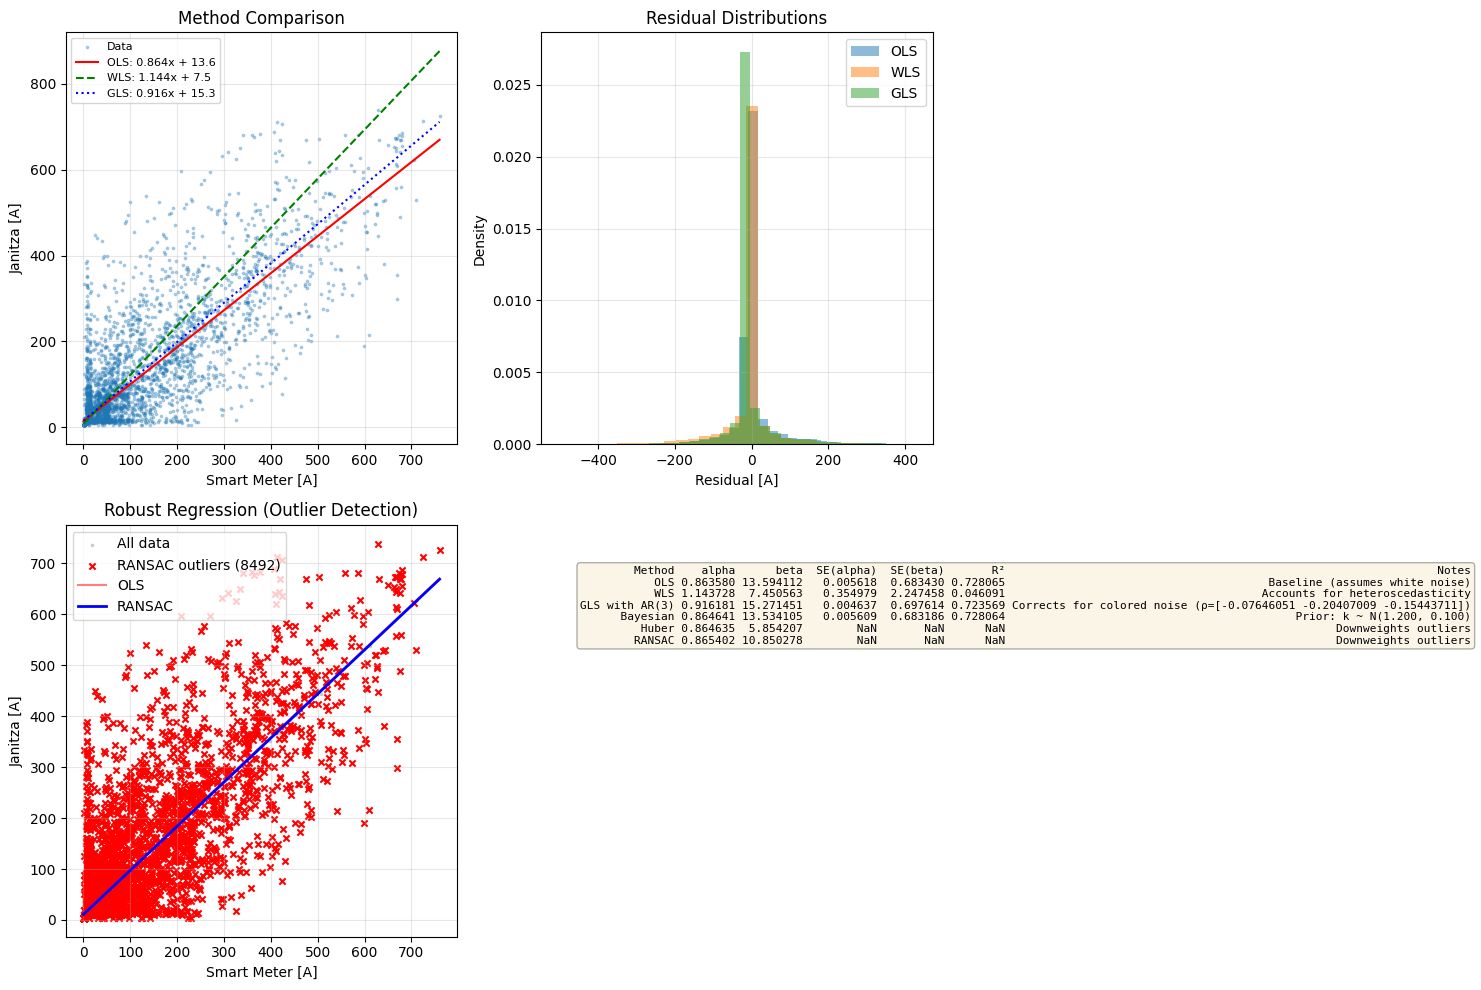

In [9]:
import numpy as np
import pandas as pd
from scipy import stats, linalg
from sklearn.linear_model import HuberRegressor, RANSACRegressor
import matplotlib.pyplot as plt
from typing import Dict, Tuple

# ============================================================================
# METHOD 1: WEIGHTED LEAST SQUARES (WLS)
# ============================================================================

def weighted_least_squares(x: np.ndarray, y: np.ndarray, 
                          weight_type: str = 'inverse_variance') -> Dict:
    """
    WLS estimation when measurement variance is heteroscedastic.
    
    weight_type options:
    - 'inverse_variance': w = 1/x² (higher current = better SNR)
    - 'uniform': w = 1 (equivalent to OLS)
    - 'robust': w = 1/(1 + residual²) (iteratively reweighted)
    """
    x = x.flatten()
    n = len(x)
    
    if weight_type == 'inverse_variance':
        # Assume measurement error variance ∝ current²
        weights = 1.0 / (x**2 + 1.0)  # +1 to avoid division by zero
    elif weight_type == 'uniform':
        weights = np.ones(n)
    elif weight_type == 'robust':
        # Iteratively reweighted least squares (IRLS)
        weights = np.ones(n)
        for _ in range(5):  # 5 iterations usually enough
            # Current fit
            X = np.column_stack([x, np.ones(n)])
            theta = np.linalg.lstsq(X * weights[:, np.newaxis], 
                                   y * weights, rcond=None)[0]
            residuals = y - (theta[0] * x + theta[1])
            # Update weights based on residuals
            s = np.median(np.abs(residuals))
            weights = 1.0 / (1.0 + (residuals / (1.4826 * s))**2)
    else:
        raise ValueError(f"Unknown weight_type: {weight_type}")
    
    # Weighted least squares
    X = np.column_stack([x, np.ones(n)])
    W = np.diag(weights)
    
    # Weighted normal equations: (X'WX)θ = X'Wy
    theta = np.linalg.lstsq(X.T @ W @ X, X.T @ W @ y, rcond=None)[0]
    alpha, beta = theta
    
    # Predictions and residuals
    y_pred = alpha * x + beta
    residuals = y - y_pred
    weighted_residuals = weights * residuals
    
    # Weighted MSE
    mse_weighted = np.sum(weights * residuals**2) / np.sum(weights)
    
    # Standard errors (corrected for weights)
    var_theta = mse_weighted * np.linalg.inv(X.T @ W @ X)
    se_alpha = np.sqrt(var_theta[0, 0])
    se_beta = np.sqrt(var_theta[1, 1])
    
    # R² (weighted)
    ss_res = np.sum(weights * residuals**2)
    ss_tot = np.sum(weights * (y - np.average(y, weights=weights))**2)
    r2_weighted = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    
    return {
        'alpha': alpha,
        'beta': beta,
        'se_alpha': se_alpha,
        'se_beta': se_beta,
        'r2_weighted': r2_weighted,
        'mse_weighted': mse_weighted,
        'weights': weights,
        'residuals': residuals,
    }

# ============================================================================
# METHOD 2: GENERALIZED LEAST SQUARES (GLS) for Colored Noise
# ============================================================================

def generalized_least_squares(x: np.ndarray, y: np.ndarray, 
                              max_ar_order: int = 3) -> Dict:
    """
    GLS estimation accounting for autocorrelated errors.
    
    Assumes AR(p) error structure: ε(t) = ρ₁ε(t-1) + ... + ρₚε(t-p) + η(t)
    where η(t) is white noise.
    """
    x = x.flatten()
    n = len(x)
    
    # Step 1: OLS to get initial residuals
    X = np.column_stack([x, np.ones(n)])
    theta_ols = np.linalg.lstsq(X, y, rcond=None)[0]
    residuals_ols = y - X @ theta_ols
    
    # Step 2: Estimate autocorrelation structure
    # Fit AR model to residuals to estimate ρ
    best_aic = np.inf
    best_rho = None
    best_p = 0
    
    for p in range(1, min(max_ar_order + 1, n // 10)):
        # Build lagged residual matrix
        Y_ar = residuals_ols[p:]
        X_ar = np.column_stack([residuals_ols[i:-(p-i)] if i < p else residuals_ols 
                                for i in range(p)])[:len(Y_ar)]
        
        if len(Y_ar) < p + 5:
            continue
            
        rho = np.linalg.lstsq(X_ar, Y_ar, rcond=None)[0]
        res_ar = Y_ar - X_ar @ rho
        
        # AIC for model selection
        sigma2 = np.var(res_ar)
        aic = 2 * p + n * np.log(sigma2)
        
        if aic < best_aic:
            best_aic = aic
            best_rho = rho
            best_p = p
    
    if best_rho is None or best_p == 0:
        # No significant autocorrelation, return OLS
        return {
            'method': 'OLS (no autocorrelation detected)',
            'alpha': theta_ols[0],
            'beta': theta_ols[1],
            'ar_order': 0,
            'rho': None,
        }
    
    # Step 3: Construct transformation matrix to whiten errors
    # For AR(1): multiply by matrix that differences at lag 1
    # General: construct Ω^(-1/2) where Ω is the error covariance
    
    if best_p == 1:
        # AR(1) case: simple differencing
        rho1 = best_rho[0]
        
        # Transform: y* = y(t) - ρ·y(t-1), x* = x(t) - ρ·x(t-1)
        y_trans = y[1:] - rho1 * y[:-1]
        x_trans = x[1:] - rho1 * x[:-1]
        intercept_trans = 1 - rho1
        
        X_trans = np.column_stack([x_trans, np.full(len(x_trans), intercept_trans)])
        
    else:
        # General AR(p): use Cholesky decomposition of Ω
        # For simplicity, use Cochrane-Orcutt transformation
        y_trans = y.copy()
        x_trans = x.copy()
        
        for lag, rho_val in enumerate(best_rho, 1):
            y_trans[lag:] -= rho_val * y[:-lag]
            x_trans[lag:] -= rho_val * x[:-lag]
        
        X_trans = np.column_stack([x_trans, np.ones(len(x_trans))])
    
    # Step 4: OLS on transformed data (= GLS on original)
    theta_gls = np.linalg.lstsq(X_trans, y_trans, rcond=None)[0]
    alpha_gls, beta_gls = theta_gls
    
    # Predictions and residuals on ORIGINAL scale
    y_pred = alpha_gls * x + beta_gls
    residuals_gls = y - y_pred
    
    # Standard errors (corrected for autocorrelation)
    residuals_trans = y_trans - X_trans @ theta_gls
    mse_trans = np.mean(residuals_trans**2)
    
    var_theta_gls = mse_trans * np.linalg.inv(X_trans.T @ X_trans)
    se_alpha = np.sqrt(var_theta_gls[0, 0])
    se_beta = np.sqrt(var_theta_gls[1, 1])
    
    # R²
    ss_res = np.sum(residuals_gls**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    
    return {
        'method': f'GLS with AR({best_p})',
        'alpha': alpha_gls,
        'beta': beta_gls,
        'se_alpha': se_alpha,
        'se_beta': se_beta,
        'r2': r2,
        'ar_order': best_p,
        'rho': best_rho,
        'residuals': residuals_gls,
    }

# ============================================================================
# METHOD 3: BAYESIAN ESTIMATION with Priors
# ============================================================================

def bayesian_regression_with_prior(x: np.ndarray, y: np.ndarray,
                                   prior_k: float, prior_k_std: float,
                                   prior_beta: float = 0.0, 
                                   prior_beta_std: float = 100.0) -> Dict:
    """
    Bayesian linear regression with informative prior on CT scaling factor.
    
    Prior: k ~ N(prior_k, prior_k_std²)  [from GridVis CT ratio]
           β ~ N(prior_beta, prior_beta_std²)  [weakly informative]
    
    Posterior is also Normal (conjugate prior).
    """
    x = x.flatten()
    n = len(x)
    
    # Design matrix
    X = np.column_stack([x, np.ones(n)])
    
    # Prior precision (inverse covariance)
    prior_precision = np.diag([1/prior_k_std**2, 1/prior_beta_std**2])
    prior_mean = np.array([prior_k, prior_beta])
    
    # OLS estimate of noise variance
    theta_ols = np.linalg.lstsq(X, y, rcond=None)[0]
    residuals_ols = y - X @ theta_ols
    sigma2_noise = np.var(residuals_ols)
    
    # Posterior precision and mean (Bayesian update)
    # Posterior precision = Prior precision + (1/σ²)·X'X
    posterior_precision = prior_precision + (1/sigma2_noise) * (X.T @ X)
    posterior_cov = np.linalg.inv(posterior_precision)
    
    # Posterior mean = Cov_post · (Precision_prior·μ_prior + (1/σ²)·X'y)
    posterior_mean = posterior_cov @ (prior_precision @ prior_mean + 
                                      (1/sigma2_noise) * (X.T @ y))
    
    alpha_bayes = posterior_mean[0]
    beta_bayes = posterior_mean[1]
    
    # Posterior standard deviations (credible intervals)
    se_alpha = np.sqrt(posterior_cov[0, 0])
    se_beta = np.sqrt(posterior_cov[1, 1])
    
    # Predictions
    y_pred = alpha_bayes * x + beta_bayes
    residuals = y - y_pred
    
    # R²
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    
    # 95% credible intervals
    alpha_ci = (alpha_bayes - 1.96 * se_alpha, alpha_bayes + 1.96 * se_alpha)
    beta_ci = (beta_bayes - 1.96 * se_beta, beta_bayes + 1.96 * se_beta)
    
    return {
        'method': 'Bayesian with CT ratio prior',
        'alpha': alpha_bayes,
        'beta': beta_bayes,
        'se_alpha': se_alpha,
        'se_beta': se_beta,
        'alpha_ci': alpha_ci,
        'beta_ci': beta_ci,
        'r2': r2,
        'posterior_cov': posterior_cov,
        'prior_k': prior_k,
        'residuals': residuals,
    }

# ============================================================================
# METHOD 4: ROBUST REGRESSION (Bonus)
# ============================================================================

def robust_regression_comparison(x: np.ndarray, y: np.ndarray) -> Dict:
    """
    Compare OLS vs Robust estimators (Huber, RANSAC).
    Robust methods downweight outliers (potential NTL events).
    """
    x = x.reshape(-1, 1)
    results = {}
    
    # OLS baseline
    X = np.column_stack([x, np.ones(len(x))])
    theta_ols = np.linalg.lstsq(X, y, rcond=None)[0]
    results['OLS'] = {'alpha': theta_ols[0], 'beta': theta_ols[1]}
    
    # Huber regression (robust to outliers)
    huber = HuberRegressor(epsilon=1.35, max_iter=100)
    huber.fit(x, y)
    results['Huber'] = {'alpha': huber.coef_[0], 'beta': huber.intercept_,
                        'outliers': huber.outliers_}
    
    # RANSAC (fits on inliers only)
    ransac = RANSACRegressor(min_samples=0.5, residual_threshold=None, 
                             max_trials=100, random_state=42)
    ransac.fit(x, y)
    results['RANSAC'] = {'alpha': ransac.estimator_.coef_[0], 
                         'beta': ransac.estimator_.intercept_,
                         'inlier_mask': ransac.inlier_mask_,
                         'n_inliers': np.sum(ransac.inlier_mask_)}
    
    return results

# ============================================================================
# COMPARISON FRAMEWORK
# ============================================================================

def compare_all_methods(x: np.ndarray, y: np.ndarray, 
                       prior_k: float = None, prior_k_std: float = 0.1) -> pd.DataFrame:
    """
    Run all methods and compare results in a table.
    """
    x = x.flatten()
    results = []
    
    # 1. Ordinary Least Squares (baseline)
    X = np.column_stack([x, np.ones(len(x))])
    theta_ols = np.linalg.lstsq(X, y, rcond=None)[0]
    y_pred_ols = X @ theta_ols
    residuals_ols = y - y_pred_ols
    se_ols = np.sqrt(np.var(residuals_ols) * np.linalg.inv(X.T @ X).diagonal())
    
    results.append({
        'Method': 'OLS',
        'alpha': theta_ols[0],
        'beta': theta_ols[1],
        'SE(alpha)': se_ols[0],
        'SE(beta)': se_ols[1],
        'R²': 1 - np.var(residuals_ols) / np.var(y),
        'Notes': 'Baseline (assumes white noise)'
    })
    
    # 2. Weighted Least Squares
    wls_result = weighted_least_squares(x, y, weight_type='inverse_variance')
    results.append({
        'Method': 'WLS',
        'alpha': wls_result['alpha'],
        'beta': wls_result['beta'],
        'SE(alpha)': wls_result['se_alpha'],
        'SE(beta)': wls_result['se_beta'],
        'R²': wls_result['r2_weighted'],
        'Notes': 'Accounts for heteroscedasticity'
    })
    
    # 3. Generalized Least Squares
    gls_result = generalized_least_squares(x, y, max_ar_order=3)
    results.append({
        'Method': gls_result['method'],
        'alpha': gls_result['alpha'],
        'beta': gls_result['beta'],
        'SE(alpha)': gls_result['se_alpha'],
        'SE(beta)': gls_result['se_beta'],
        'R²': gls_result['r2'],
        'Notes': f"Corrects for colored noise (ρ={gls_result['rho']})"
    })
    
    # 4. Bayesian (if prior provided)
    if prior_k is not None:
        bayes_result = bayesian_regression_with_prior(
            x, y, prior_k=prior_k, prior_k_std=prior_k_std
        )
        results.append({
            'Method': 'Bayesian',
            'alpha': bayes_result['alpha'],
            'beta': bayes_result['beta'],
            'SE(alpha)': bayes_result['se_alpha'],
            'SE(beta)': bayes_result['se_beta'],
            'R²': bayes_result['r2'],
            'Notes': f"Prior: k ~ N({prior_k:.3f}, {prior_k_std:.3f})"
        })
    
    # 5. Robust methods
    robust_results = robust_regression_comparison(x, y)
    for method, res in robust_results.items():
        if method != 'OLS':  # Already have OLS
            results.append({
                'Method': method,
                'alpha': res['alpha'],
                'beta': res['beta'],
                'SE(alpha)': np.nan,
                'SE(beta)': np.nan,
                'R²': np.nan,
                'Notes': 'Downweights outliers'
            })
    
    return pd.DataFrame(results)


# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_method_comparison(x: np.ndarray, y: np.ndarray, 
                          prior_k: float = None):
    """
    Visual comparison of different estimation methods.
    """
    x = x.flatten()
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Get all estimates
    ols = np.polyfit(x, y, 1)
    wls = weighted_least_squares(x, y)
    gls = generalized_least_squares(x, y)
    robust = robust_regression_comparison(x, y)
    
    x_line = np.linspace(x.min(), x.max(), 100)
    
    # Plot 1: All fits overlaid
    ax = axes[0, 0]
    ax.scatter(x, y, s=3, alpha=0.3, label='Data')
    ax.plot(x_line, ols[0] * x_line + ols[1], 'r-', label=f'OLS: {ols[0]:.3f}x + {ols[1]:.1f}')
    ax.plot(x_line, wls['alpha'] * x_line + wls['beta'], 'g--', 
            label=f"WLS: {wls['alpha']:.3f}x + {wls['beta']:.1f}")
    ax.plot(x_line, gls['alpha'] * x_line + gls['beta'], 'b:', 
            label=f"GLS: {gls['alpha']:.3f}x + {gls['beta']:.1f}")
    ax.set_xlabel('Smart Meter [A]')
    ax.set_ylabel('Janitza [A]')
    ax.set_title('Method Comparison')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Residuals comparison
    ax = axes[0, 1]
    res_ols = y - (ols[0] * x + ols[1])
    res_wls = wls['residuals']
    res_gls = gls['residuals']
    
    ax.hist(res_ols, bins=30, alpha=0.5, label='OLS', density=True)
    ax.hist(res_wls, bins=30, alpha=0.5, label='WLS', density=True)
    ax.hist(res_gls, bins=30, alpha=0.5, label='GLS', density=True)
    ax.set_xlabel('Residual [A]')
    ax.set_ylabel('Density')
    ax.set_title('Residual Distributions')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Robust vs OLS
    ax = axes[1, 0]
    ax.scatter(x, y, s=3, alpha=0.3, c='gray', label='All data')
    if 'inlier_mask' in robust['RANSAC']:
        inliers = robust['RANSAC']['inlier_mask']
        ax.scatter(x[~inliers], y[~inliers], s=20, c='red', marker='x', 
                  label=f"RANSAC outliers ({np.sum(~inliers)})")
    ax.plot(x_line, ols[0] * x_line + ols[1], 'r-', alpha=0.5, label='OLS')
    ax.plot(x_line, robust['RANSAC']['alpha'] * x_line + robust['RANSAC']['beta'], 
            'b-', linewidth=2, label='RANSAC')
    ax.set_xlabel('Smart Meter [A]')
    ax.set_ylabel('Janitza [A]')
    ax.set_title('Robust Regression (Outlier Detection)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Parameter comparison table
    ax = axes[1, 1]
    ax.axis('off')
    
    comparison_df = compare_all_methods(x, y, prior_k=prior_k)
    
    table_text = comparison_df.to_string(index=False)
    ax.text(0.1, 0.9, table_text, transform=ax.transAxes, 
            fontsize=8, verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.show()


sub_411 = df_merged[df_merged['substation_id'] == 1528]

# Step 2: Extract the arrays
x = sub_411['I_total_sm'].values   # This is now a numpy array
y = sub_411['I_total_jn'].values   # This is now a numpy array


# Example usage:
comparison_df = compare_all_methods(x, y, prior_k=1.2)
print(comparison_df)
plot_method_comparison(x, y, prior_k=1.2)

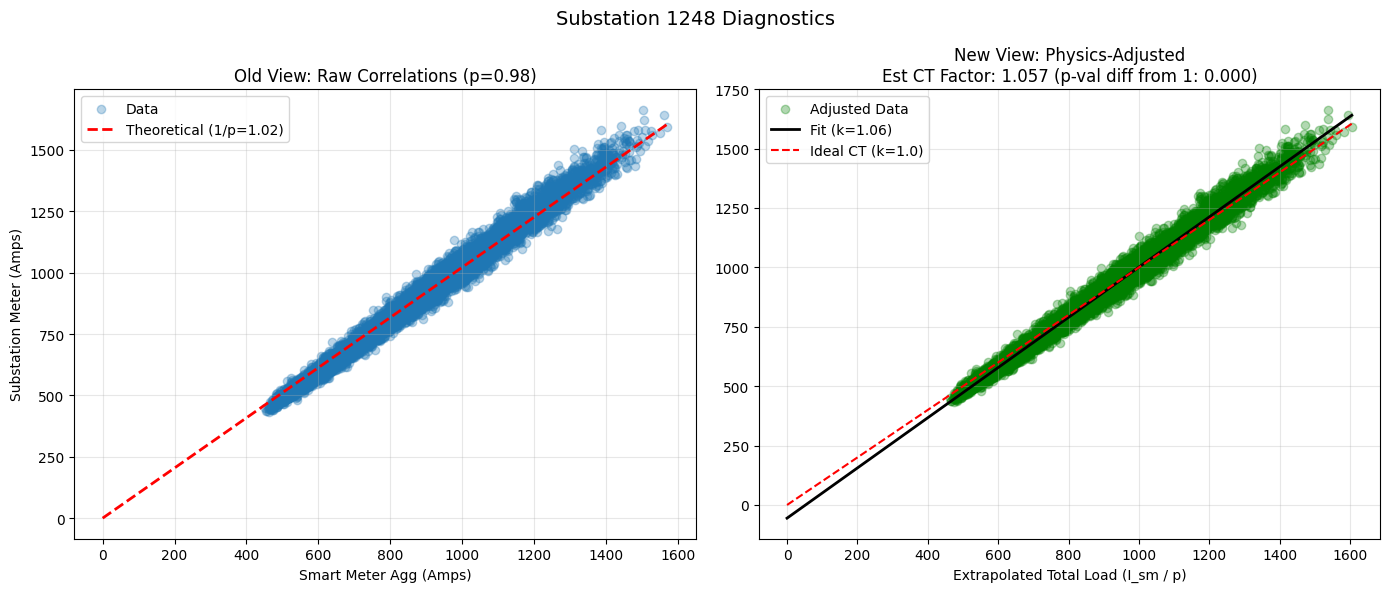

In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

def analyze_substation_physics_aware(df_sub, 
                                     sub_id_col='substation_id',
                                     sm_col='I_total_sm', 
                                     jn_col='I_total_jn', 
                                     cov_col='per_completed'):
    """
    Performs physics-informed OLS regression for a single substation.
    Model: I_J = beta_ct * (I_SM / p) + beta_base + error
    """
    
    # 1. Pre-checks
    if len(df_sub) < 50:  # Arbitrary min points threshold
        return None
    
    # Ensure no division by zero or NaNs
    df_clean = df_sub[df_sub[cov_col] > 0.01].copy()
    df_clean = df_clean.dropna(subset=[sm_col, jn_col, cov_col])
    
    if len(df_clean) < 50:
        return None

    # 2. Feature Engineering: The 'Expected' Load
    # X_adj is what the substation SHOULD see if CTs are perfect (k=1)
    X_adj = df_clean[sm_col] / df_clean[cov_col]
    Y = df_clean[jn_col]
    
    # Add constant for intercept (beta_base)
    X_matrix = sm.add_constant(X_adj)
    
    # 3. Fit OLS Model with Robust Standard Errors (HC3)
    # We use HC3 because power data residuals often have variance proportional to load (heteroskedasticity)
    model = sm.OLS(Y, X_matrix)
    results = model.fit(cov_type='HC3')
    
    # 4. Extract Parameters (robust to param index naming/order)
    params = results.params
    ci = results.conf_int(alpha=0.05)
    bse = results.bse
    pvals = results.pvalues

    # Identify intercept (usually 'const') and slope parameter
    if 'const' in params.index:
        intercept = float(params['const'])
        intercept_se = float(bse.get('const', np.nan))
        intercept_p = float(pvals.get('const', np.nan))
        slope_name = [n for n in params.index if n != 'const'][0]
    else:
        # If no explicit constant, treat first param as slope
        intercept = np.nan
        intercept_se = np.nan
        intercept_p = np.nan
        slope_name = params.index[0]

    slope = float(params[slope_name])

    # Confidence interval for slope
    slope_conf_vals = ci.loc[slope_name].values
    slope_conf_lower, slope_conf_upper = float(slope_conf_vals[0]), float(slope_conf_vals[1])

    # Standard error for slope
    slope_se = float(bse[slope_name])

    # 5. Hypothesis Testing
    # Test A: Is CT factor significantly different from 1.0?
    # t = (beta - 1) / std_err
    if slope_se == 0 or np.isnan(slope_se):
        t_stat_unity = np.nan
        p_val_unity = np.nan
    else:
        t_stat_unity = (slope - 1) / slope_se
        from scipy import stats
        p_val_unity = 2 * (1 - stats.t.cdf(abs(t_stat_unity), df=results.df_resid))

    # 6. Residual Analysis
    residuals = results.resid
    resid_std = residuals.std()
    
    # Residual share (What % of variance is NOT explained by CT + Coverage?)
    # Lower is better. If high, implies NTL or massive timing mismatches.
    resid_variance_share = residuals.var() / Y.var()
    
    # Autocorrelation (Lag 1) - helps detect if residuals have structure (NTL pattern)
    resid_ac1 = residuals.autocorr(lag=1)
    
    # Durbin-Watson (approx 2 is white noise, <1 is positive correlation)
    dw_stat = durbin_watson(residuals)

    # 7. Construct Result Dictionary
    return {
        'substation_id': df_clean[sub_id_col].iloc[0],
        'n_points': int(results.nobs),
        'r_squared': results.rsquared,
        
        # CT Estimation (The Slope)
        'ct_factor_est': slope,
        'ct_factor_se': slope_se,
        'ct_factor_ci_lower': slope_conf_lower,
        'ct_factor_ci_upper': slope_conf_upper,
        'is_ct_correct': (p_val_unity > 0.05) if not np.isnan(p_val_unity) else False, # Fail to reject H0: slope=1
        'p_value_unity_test': p_val_unity,   # < 0.05 means significantly distorted CT
        
        # Baseline Estimation (The Intercept)
        'intercept_est': intercept,
        'intercept_se': intercept_se,
        'intercept_p_val': intercept_p,
        
        # Residual Diagnostics (NTL indicators)
        'resid_std': resid_std,
        'resid_var_share': resid_variance_share,
        'resid_ac1': resid_ac1,
        'dw_stat': dw_stat,
        'mean_coverage': df_clean[cov_col].mean() # For reference
    }

def run_batch_analysis(merged_df):

    results_list = []
    
    # Group by substation
    for sub_id, sub_df in merged_df.groupby('substation_id'):
        res = analyze_substation_physics_aware(sub_df)
        if res:
            results_list.append(res)
            
    return pd.DataFrame(results_list)

def classify_substation_status(row):
    """
    Classifies substation state based on regression outputs.
    """
    # 1. Check Data Quality / Fit
    if row['r_squared'] < 0.80:
        return "POOR_FIT_UNUSABLE"
    
    # 2. Check CT Scaling (Is slope approx 1?)
    # We use the p-value for H0: slope=1. If p < 0.01, we are very sure it's NOT 1.
    ct_is_one = row['p_value_unity_test'] > 0.01 
    
    # Alternatively, use technical bounds (e.g., 0.9 < k < 1.1 is acceptable)
    ct_technically_ok = (0.9 < row['ct_factor_est'] < 1.1)
    
    ct_status = "OK" if (ct_is_one or ct_technically_ok) else "CT_ERROR"
    
    # 3. Check Residuals for Suspicious Activity (NTL)
    # If residual variance is high (> 5-10% of total variance) OR High Autocorrelation
    is_noisy = (row['resid_var_share'] > 0.10) or (row['resid_ac1'] > 0.7)
    
    if ct_status == "CT_ERROR":
        if is_noisy:
            return "CT_ERROR_PLUS_NOISE" # Hard to separate NTL from CT error
        else:
            return "PURE_CT_SCALING_ISSUE" # Clean linear fit, just wrong slope
            
    elif ct_status == "OK":
        if is_noisy:
            return "SUSPICIOUS_NTL_CANDIDATE" # CT looks good, but unaccounted variance
        else:
            return "CLEAN_OK" # CT matches coverage, low noise
            
    return "UNDEFINED"

def plot_model_comparison(sub_id, merged_df, stats_df):
    sub_data = merged_df[merged_df['substation_id'] == sub_id].copy()
    sub_stats = stats_df[stats_df['substation_id'] == sub_id].iloc[0]
    
    if sub_data.empty: return

    p = sub_data['per_completed'].mean()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- Plot 1: Old Approach (Raw Data) ---
    # x = I_sm, y = I_jn. Expected slope = 1/p
    axes[0].scatter(sub_data['I_total_sm'], sub_data['I_total_jn'], alpha=0.3, label='Data')
    
    # Theoretical "Perfect" Line (slope = 1/p)
    x_range = np.linspace(0, sub_data['I_total_sm'].max(), 100)
    axes[0].plot(x_range, x_range * (1/p), 'r--', lw=2, label=f'Theoretical (1/p={1/p:.2f})')
    
    axes[0].set_title(f"Old View: Raw Correlations (p={p:.2f})")
    axes[0].set_xlabel("Smart Meter Agg (Amps)")
    axes[0].set_ylabel("Substation Meter (Amps)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # --- Plot 2: New Approach (Physics Aware) ---
    # x = I_sm / p, y = I_jn. Expected slope = 1.0 (CT Factor)
    x_adj = sub_data['I_total_sm'] / sub_data['per_completed']
    y = sub_data['I_total_jn']
    
    axes[1].scatter(x_adj, y, alpha=0.3, c='green', label='Adjusted Data')
    
    # The Model Fit
    k_est = sub_stats['ct_factor_est']
    b_est = sub_stats['intercept_est']
    
    x_range_adj = np.linspace(0, x_adj.max(), 100)
    y_pred = k_est * x_range_adj + b_est
    
    axes[1].plot(x_range_adj, y_pred, 'k-', lw=2, label=f'Fit (k={k_est:.2f})')
    
    # Ideal Line (k=1)
    axes[1].plot(x_range_adj, x_range_adj, 'r--', lw=1.5, label='Ideal CT (k=1.0)')

    axes[1].set_title(f"New View: Physics-Adjusted\nEst CT Factor: {k_est:.3f} (p-val diff from 1: {sub_stats['p_value_unity_test']:.3f})")
    axes[1].set_xlabel("Extrapolated Total Load (I_sm / p)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f"Substation {sub_id} Diagnostics", fontsize=14)
    plt.tight_layout()
    plt.show()

df_test = run_batch_analysis(df_merged) #the code below works ask gemini for help later
df_test.head()

plot_model_comparison(1248, df_merged, df_test)